# 🩸 Blood Cell Anomaly Detection — Complete End-to-End Analysis

---

> **Inspired by:** *Deep Generative Classification of Blood Cell Morphology — CytoDiffusion*  
> **Published in:** Nature Machine Intelligence (2025)  
> **Institutions:** University of Cambridge · University College London · Queen Mary University of London

---

## 📌 Project Overview

This notebook presents a **complete clinical AI pipeline** for detecting anomalous blood cells from morphological, colorimetric, and clinical features. We analyze **5,880 blood cell records** across **19 cell types** to build explainable, high-recall models suitable for clinical screening.

### 🎯 Objectives
1. **Exploratory Data Analysis (EDA)** — Understand distributions, relationships, and clinical patterns
2. **Feature Engineering** — Craft biologically meaningful derived features
3. **Binary Classification** — Normal vs. Anomaly detection
4. **Multi-class Classification** — Identify all 19 cell types
5. **Disease-level Prediction** — Map cells to disease categories
6. **Model Explainability** — SHAP analysis + Feature Importance
7. **Benchmark Comparison** — Evaluate against published CytoDiffusion paper metrics

### 📁 Dataset Files
| File | Description |
|------|-------------|
| `blood_cell_anomaly_detection.csv` | Main dataset — 5,880 cells × 36 features |
| `cell_type_reference.csv` | Clinical reference for each cell type |
| `cytodiffusion_benchmark_scores.csv` | Published benchmark metrics from the paper |

---

## ⚙️ Step 1: Environment Setup & Library Imports

In [1]:
# ============================================================
#  Core Libraries
# ============================================================
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
#  Visualization Libraries
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ============================================================
#  Machine Learning — Preprocessing & Evaluation
# ============================================================
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

# ============================================================
#  Machine Learning — Models
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ============================================================
#  Explainability
# ============================================================
import shap

# ============================================================
#  Global Aesthetic Configuration
# ============================================================
PALETTE_MAIN  = ['#C0392B', '#2980B9', '#27AE60', '#F39C12', '#8E44AD', '#16A085', '#2C3E50']
COLOR_NORMAL  = '#27AE60'  # Green  → Normal cells
COLOR_ANOMALY = '#C0392B'  # Red    → Anomalous cells
COLOR_ACCENT  = '#2980B9'  # Blue   → Accent
BG_COLOR      = '#F0F4F8'
CARD_COLOR    = '#FFFFFF'

# Custom diverging colormap (red-white-green)
RWG = LinearSegmentedColormap.from_list('rwg', ['#C0392B', '#FFFFFF', '#27AE60'])

plt.rcParams.update({
    'figure.facecolor'   : BG_COLOR,
    'axes.facecolor'     : CARD_COLOR,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : True,
    'axes.spines.bottom' : True,
    'axes.grid'          : True,
    'grid.color'         : '#E8ECF0',
    'grid.linewidth'     : 0.7,
    'grid.linestyle'     : '--',
    'font.family'        : 'DejaVu Sans',
    'axes.labelsize'     : 11,
    'axes.titlesize'     : 13,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'legend.fontsize'    : 9,
    'figure.dpi'         : 120,
})

print('✅  All libraries loaded successfully!')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
print(f'   SHAP   : {shap.__version__}')

✅  All libraries loaded successfully!
   NumPy  : 2.4.3
   Pandas : 3.0.1
   SHAP   : 0.51.0


---
## 📂 Step 2: Data Loading & Initial Inspection

> **Best Practice:** Before any modeling, verify data integrity — volume, schema, missing values, and data types. Catching issues here saves hours of debugging downstream.

In [2]:
# ============================================================
#  File Paths — Update these to match your local environment
# ============================================================
BASE_PATH  = r'D:\Projects--Kaggle-\Blood-Cell-Anomaly-Detection\Dataset'

MAIN_PATH  = os.path.join(BASE_PATH, 'blood_cell_anomaly_detection.csv')
REF_PATH   = os.path.join(BASE_PATH, 'cell_type_reference.csv')
BENCH_PATH = os.path.join(BASE_PATH, 'cytodiffusion_benchmark_scores.csv')

# Load all three datasets
df    = pd.read_csv(MAIN_PATH)
ref   = pd.read_csv(REF_PATH)
bench = pd.read_csv(BENCH_PATH)

# ─────────────────────────────────────────
#  Quick sanity checks
# ─────────────────────────────────────────
print('=' * 55)
print('  📊  BLOOD CELL ANOMALY DETECTION — DATA SUMMARY')
print('=' * 55)
print(f'  Main dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Unique cell types   : {df.cell_type.nunique()}')
print(f'  Normal cells (0)    : {(df.anomaly_label==0).sum():,}')
print(f'  Anomaly cells (1)   : {(df.anomaly_label==1).sum():,}')
print(f'  Anomaly rate        : {(df.anomaly_label==1).mean()*100:.1f}%')
print(f'  Missing values      : {df.isnull().sum().sum()}')
print('=' * 55)

df.head()

  📊  BLOOD CELL ANOMALY DETECTION — DATA SUMMARY
  Main dataset shape  : 5,880 rows × 36 columns
  Unique cell types   : 19
  Normal cells (0)    : 4,000
  Anomaly cells (1)   : 1,880
  Anomaly rate        : 32.0%
  Missing values      : 0


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [3]:
# ─────────────────────────────────────────
#  Data Types & Memory Usage
# ─────────────────────────────────────────
print('\n--- Column Data Types & Null Counts ---')
info_df = pd.DataFrame({
    'dtype'  : df.dtypes,
    'nulls'  : df.isnull().sum(),
    'unique' : df.nunique(),
    '%null'  : (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())

print(f'\n💾  Total Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')


--- Column Data Types & Null Counts ---
                                           dtype  nulls  unique  %null
cell_id                                      str      0    5880    0.0
cell_type                                    str      0      19    0.0
anomaly_label                              int64      0       2    0.0
disease_category                             str      0       8    0.0
cell_diameter_um                         float64      0    1472    0.0
nucleus_area_pct                         float64      0     607    0.0
chromatin_density                        float64      0     730    0.0
cytoplasm_ratio                          float64      0     610    0.0
circularity                              float64      0     727    0.0
eccentricity                             float64      0     878    0.0
granularity_score                        float64      0     566    0.0
lobularity_score                         float64      0      63    0.0
membrane_smoothness                 

**🔍 Key Observations — Data Overview:**
- **Zero missing values** across all 36 columns — no imputation required.
- **8 categorical** and **28 numerical** features covering morphology, color, and clinical blood metrics.
- **31.97% anomaly rate** — mild class imbalance; we'll use stratified splits and recall-optimized metrics.
- `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, and `labeller_confidence_score` are **meta-scores** (potential data leakage — addressed in Step 6).

---

## 📊 Step 3: Exploratory Data Analysis (EDA)

### 3.1 — Target Variable & Cell Type Distribution

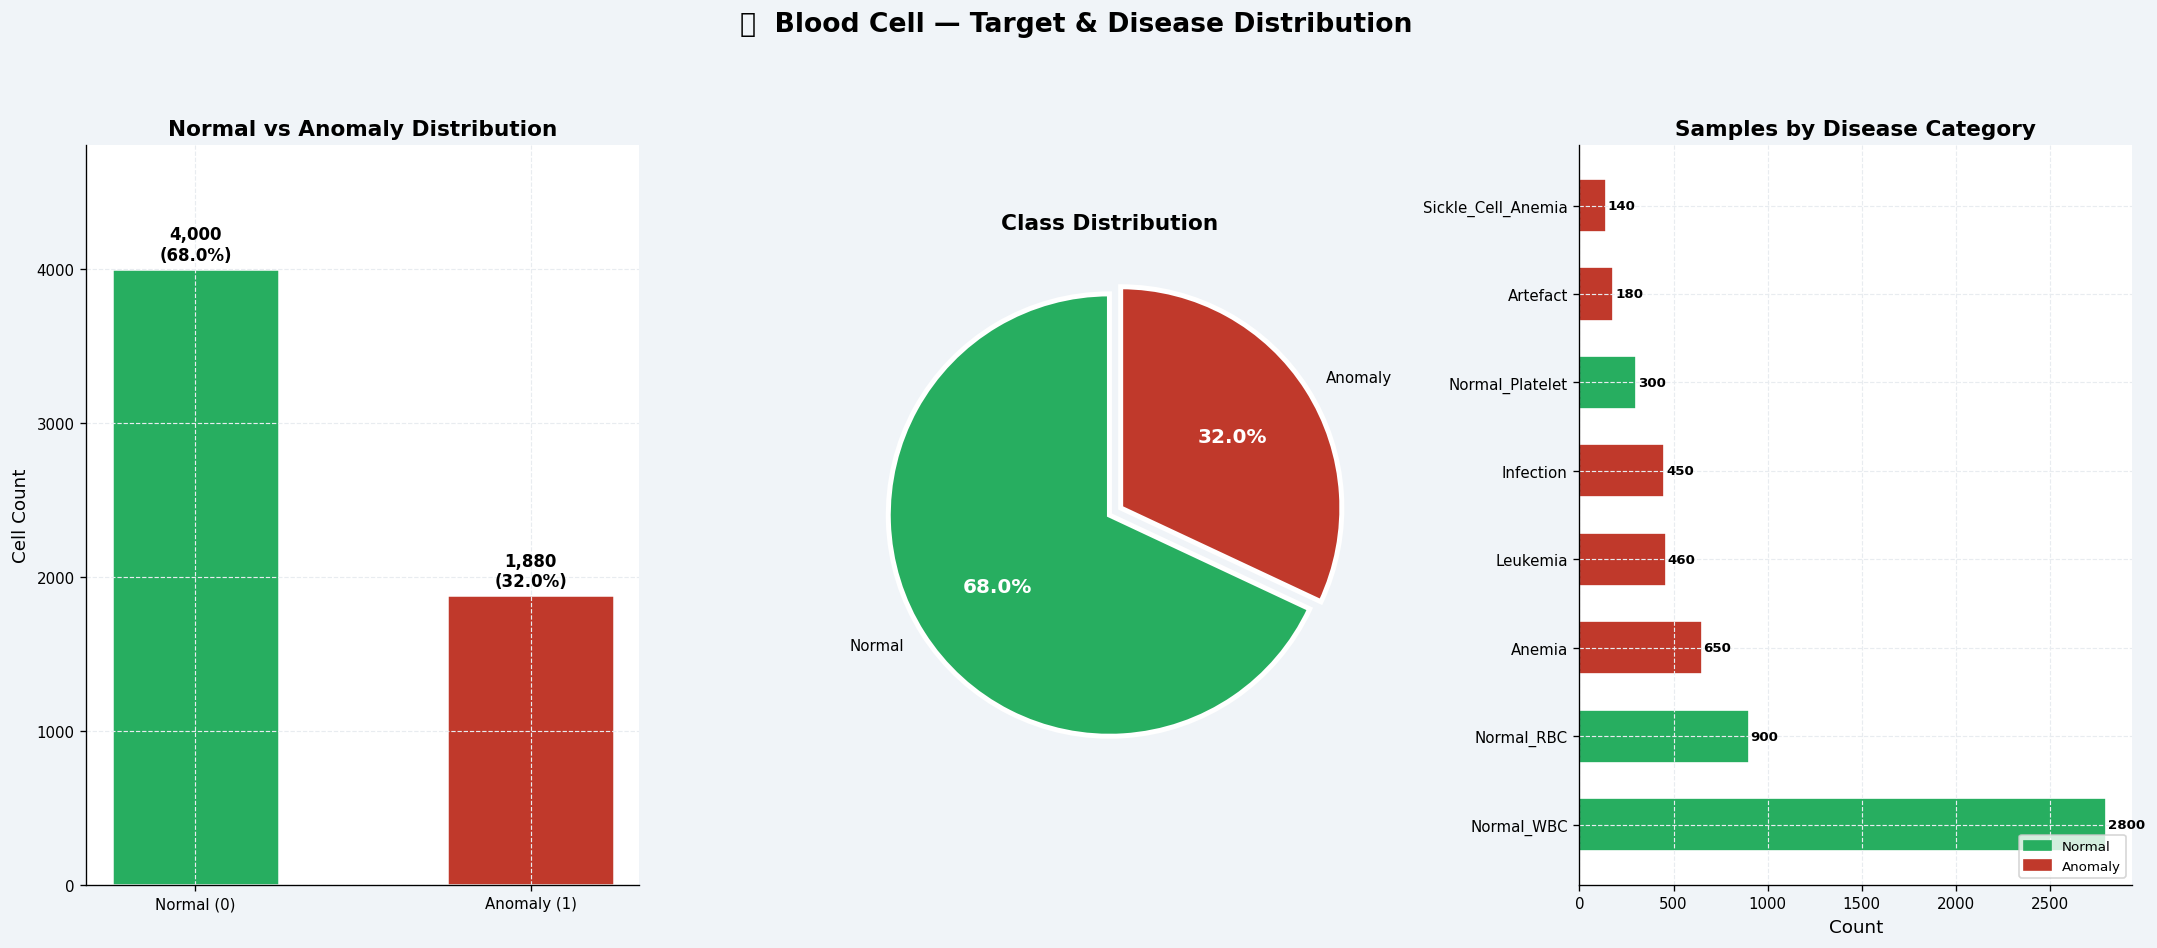


🔍 Observation: Mild class imbalance (~32% anomaly). Normal categories dominate (4,000 cells).
   Disease categories span Leukemia, Anemia, Infection, Sickle Cell, and Artefact.


In [4]:
fig = plt.figure(figsize=(22, 8), facecolor=BG_COLOR)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ─── Panel 1: Normal vs Anomaly Count ───
ax1 = fig.add_subplot(gs[0])
counts = df['anomaly_label'].value_counts().sort_index()
bars   = ax1.bar(['Normal (0)', 'Anomaly (1)'], counts.values,
                  color=[COLOR_NORMAL, COLOR_ANOMALY],
                  edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Normal vs Anomaly Distribution', fontweight='bold')
ax1.set_ylabel('Cell Count')
ax1.set_ylim(0, counts.max() * 1.2)

# ─── Panel 2: Pie Chart ───
ax2 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=['Normal', 'Anomaly'],
    colors=[COLOR_NORMAL, COLOR_ANOMALY],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=3),
    explode=(0, 0.06)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
    t.set_color('white')
ax2.set_title('Class Distribution', fontweight='bold')

# ─── Panel 3: Disease Category ───
ax3 = fig.add_subplot(gs[2])
cat_c = df['disease_category'].value_counts()
normal_cats = ['Normal_WBC', 'Normal_RBC', 'Normal_Platelet']
bar_colors  = [COLOR_NORMAL if c in normal_cats else COLOR_ANOMALY for c in cat_c.index]
h_bars = ax3.barh(cat_c.index, cat_c.values, color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(h_bars, cat_c.values):
    ax3.text(val + 10, bar.get_y() + bar.get_height()/2, str(val),
             va='center', fontsize=8, fontweight='bold')
ax3.set_title('Samples by Disease Category', fontweight='bold')
ax3.set_xlabel('Count')
normal_patch  = mpatches.Patch(color=COLOR_NORMAL, label='Normal')
anomaly_patch = mpatches.Patch(color=COLOR_ANOMALY, label='Anomaly')
ax3.legend(handles=[normal_patch, anomaly_patch], loc='lower right', fontsize=8)

fig.suptitle('🩸  Blood Cell — Target & Disease Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🔍 Observation: Mild class imbalance (~32% anomaly). Normal categories dominate (4,000 cells).')
print('   Disease categories span Leukemia, Anemia, Infection, Sickle Cell, and Artefact.')

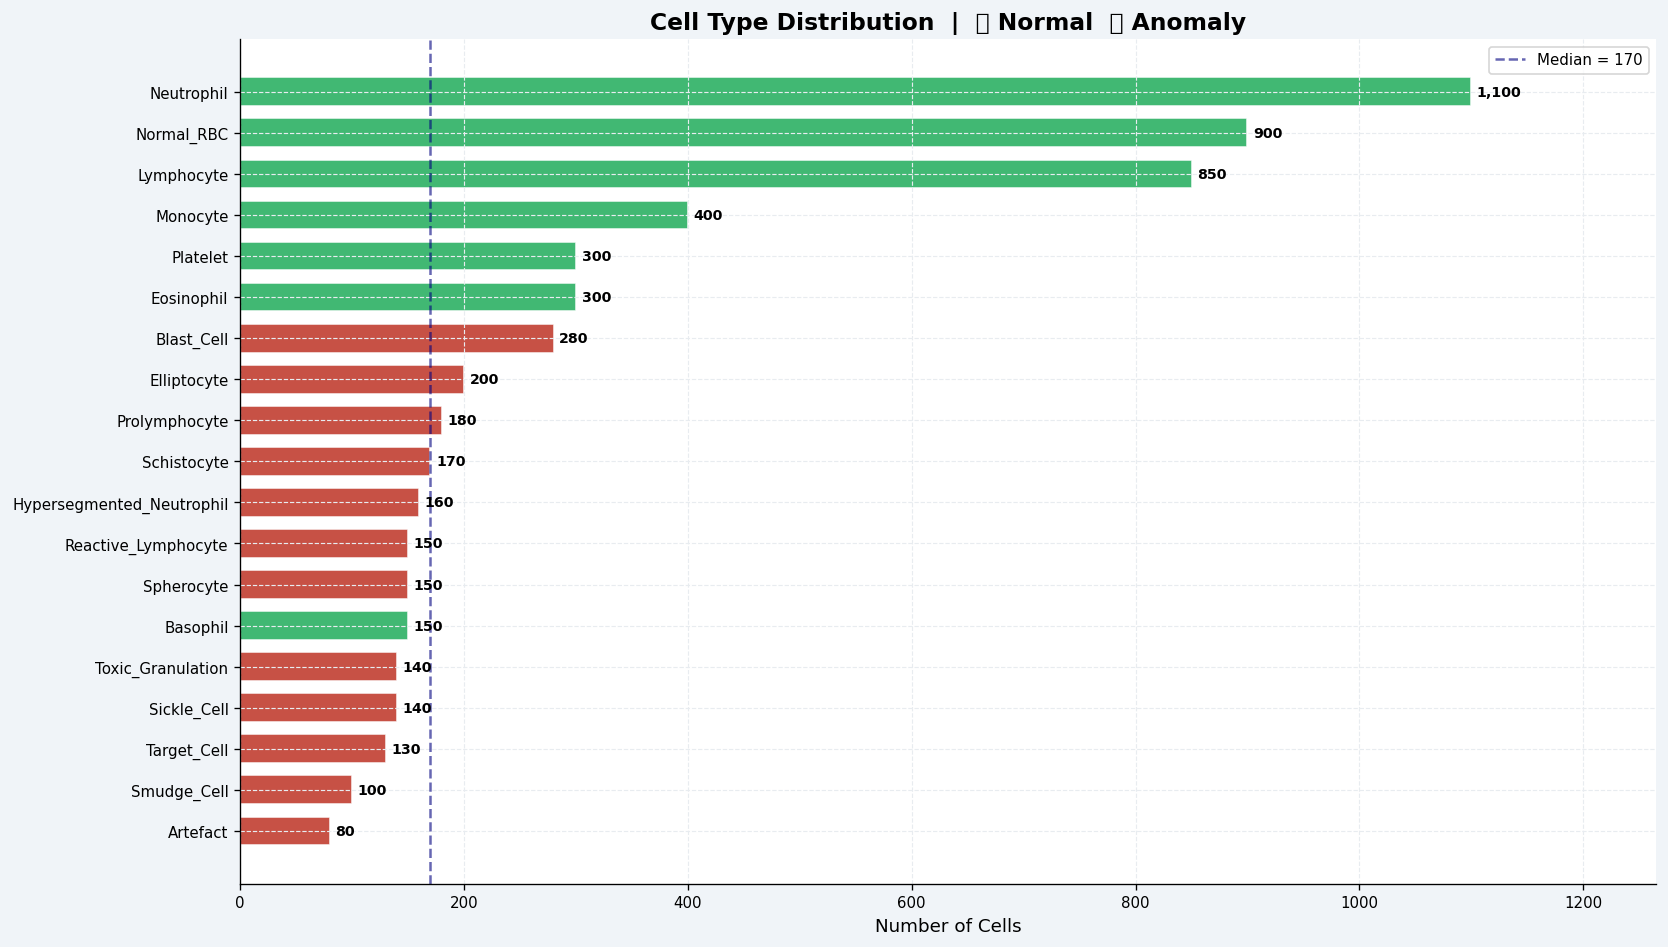


🔍 Key Observations:
   • Neutrophil (1,100) and Lymphocyte (850) dominate among normal cells.
   • Artefact (80) and Smudge_Cell (100) are the rarest anomaly types.
   • Blast_Cell (280) is the most represented leukemia cell — critical for detection.


In [5]:
# ─── Cell Type Distribution (all 19 types) ───
fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG_COLOR)

vc     = df['cell_type'].value_counts().sort_values(ascending=True)
c_map  = df.drop_duplicates('cell_type').set_index('cell_type')['anomaly_label'].to_dict()
colors = [COLOR_ANOMALY if c_map.get(c, 0) == 1 else COLOR_NORMAL for c in vc.index]

bars = ax.barh(vc.index, vc.values, color=colors, edgecolor='white', height=0.7, alpha=0.88)
for bar, val in zip(bars, vc.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Number of Cells', fontsize=11)
ax.set_title('Cell Type Distribution  |  🟢 Normal  🔴 Anomaly', fontweight='bold', fontsize=14)
ax.set_xlim(0, vc.max() * 1.15)

# Add vertical line at median
ax.axvline(vc.median(), color='navy', lw=1.5, ls='--', alpha=0.6, label=f'Median = {vc.median():.0f}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔍 Key Observations:')
print('   • Neutrophil (1,100) and Lymphocyte (850) dominate among normal cells.')
print('   • Artefact (80) and Smudge_Cell (100) are the rarest anomaly types.')
print('   • Blast_Cell (280) is the most represented leukemia cell — critical for detection.')

### 3.2 — Clinical Reference Table

In [6]:
# ─── Display Clinical Reference with Styled Output ───
print('=' * 60)
print('    📋  CELL TYPE CLINICAL REFERENCE')
print('=' * 60)
print(ref.to_string(index=False))

print('\n🔍 Key Clinical Insights from Reference Table:')
print('   • CRITICAL — Blast Cells are leukemia hallmarks; missing them is clinically catastrophic.')
print('   • Sickle Cells (HbS mutation) and Schistocytes (fragmented RBCs) have distinctive morphology.')
print('   • Smudge Cells appear on blood smears when fragile lymphocytes rupture during preparation.')
print('   • Hypersegmented Neutrophils (5+ lobes) indicate B12/Folate deficiency.')

    📋  CELL TYPE CLINICAL REFERENCE
                cell_type   disease_category  anomaly_label                                           clinical_significance  count_in_dataset
               Neutrophil         Normal_WBC              0            Primary bacterial infection fighter; most common WBC              1100
               Lymphocyte         Normal_WBC              0                 Adaptive immunity; elevated in viral infections               850
                 Monocyte         Normal_WBC              0                             Phagocyte; precursor to macrophages               400
               Eosinophil         Normal_WBC              0                            Allergic response & parasite defense               300
                 Basophil         Normal_WBC              0                Least common WBC; involved in allergic reactions               150
               Normal_RBC         Normal_RBC              0                          Oxygen transport; biconcave

### 3.3 — Patient Demographics Analysis

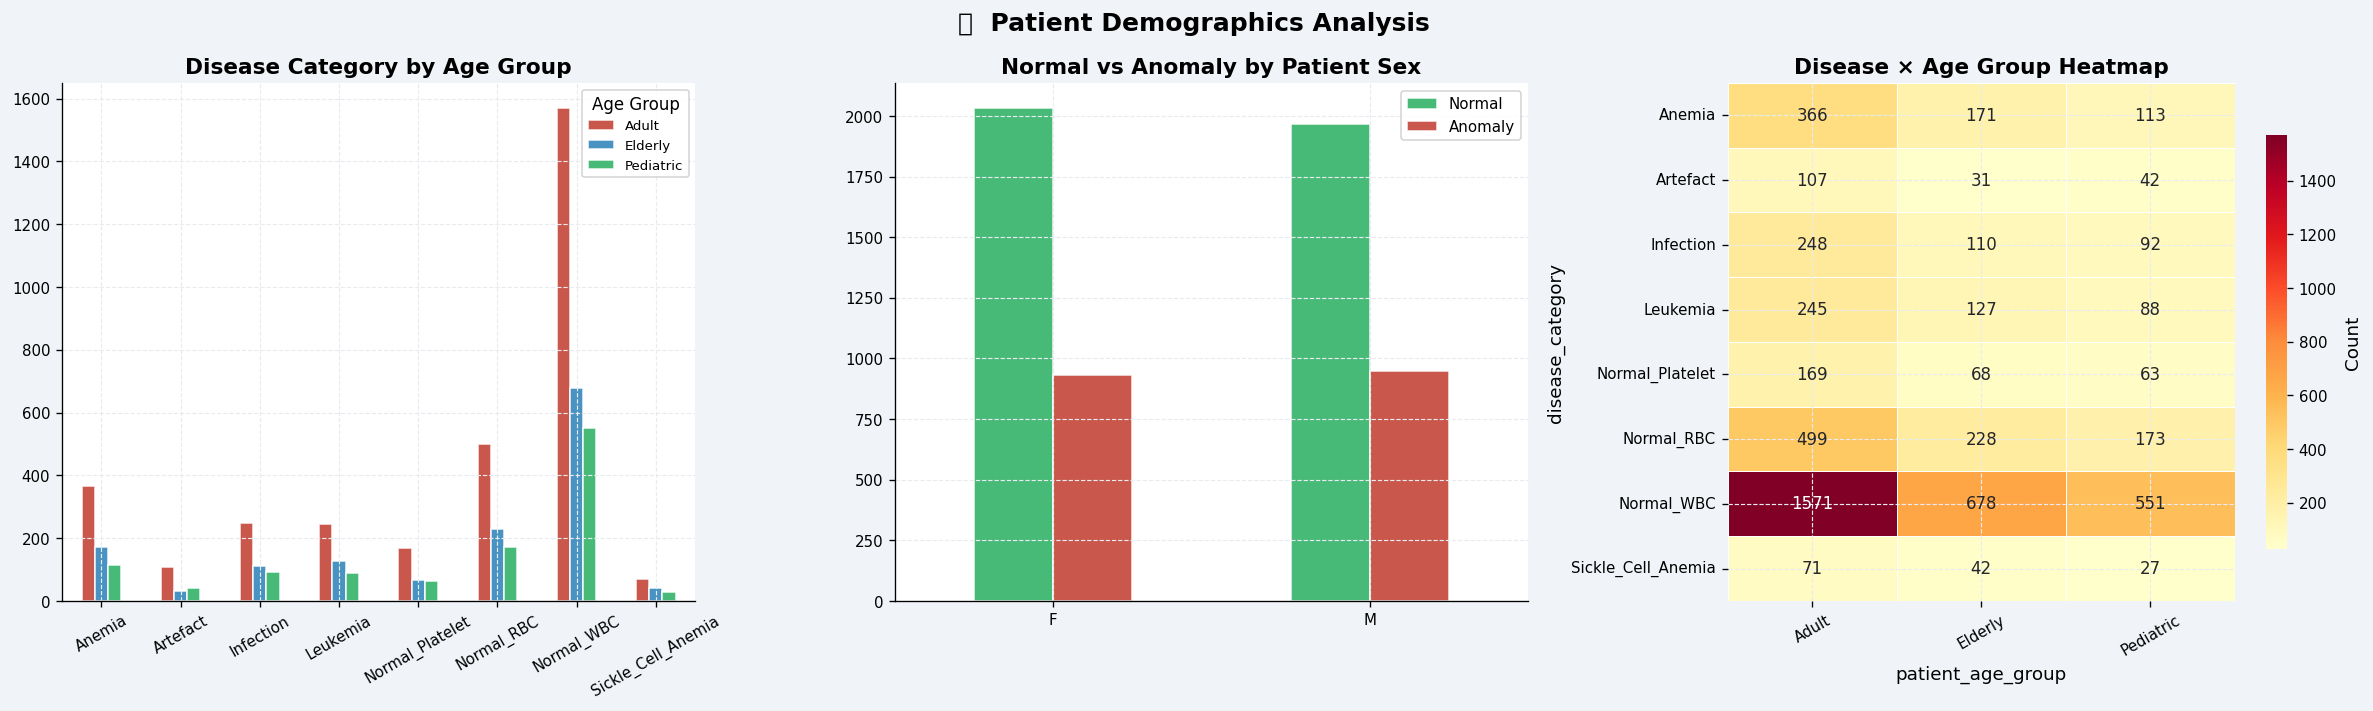


🔍 Demographic Insights:
   • Leukemia cells appear across all age groups, but slightly more in adults.
   • Sex distribution is relatively balanced — no strong sex-based bias in anomaly rates.
   • Anemia shows a higher representation in the elder + adult groups — clinically expected.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG_COLOR)

# ─── Age Group vs Disease ───
ct_age = pd.crosstab(df['disease_category'], df['patient_age_group'])
ct_age.plot(kind='bar', ax=axes[0], color=PALETTE_MAIN[:3], edgecolor='white', alpha=0.85)
axes[0].set_title('Disease Category by Age Group', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Age Group', fontsize=8)

# ─── Sex Distribution ───
sex_anomaly = df.groupby(['patient_sex', 'anomaly_label']).size().unstack()
sex_anomaly.plot(kind='bar', ax=axes[1], color=[COLOR_NORMAL, COLOR_ANOMALY], edgecolor='white', alpha=0.85)
axes[1].set_title('Normal vs Anomaly by Patient Sex', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Normal', 'Anomaly'], fontsize=9)

# ─── Cross-tab Heatmap: Age × Disease ───
sns.heatmap(ct_age, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            linewidths=0.5, cbar_kws={'label': 'Count', 'shrink': 0.8})
axes[2].set_title('Disease × Age Group Heatmap', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle('👥  Patient Demographics Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Demographic Insights:')
print('   • Leukemia cells appear across all age groups, but slightly more in adults.')
print('   • Sex distribution is relatively balanced — no strong sex-based bias in anomaly rates.')
print('   • Anemia shows a higher representation in the elder + adult groups — clinically expected.')

### 3.4 — Morphological Feature Distributions

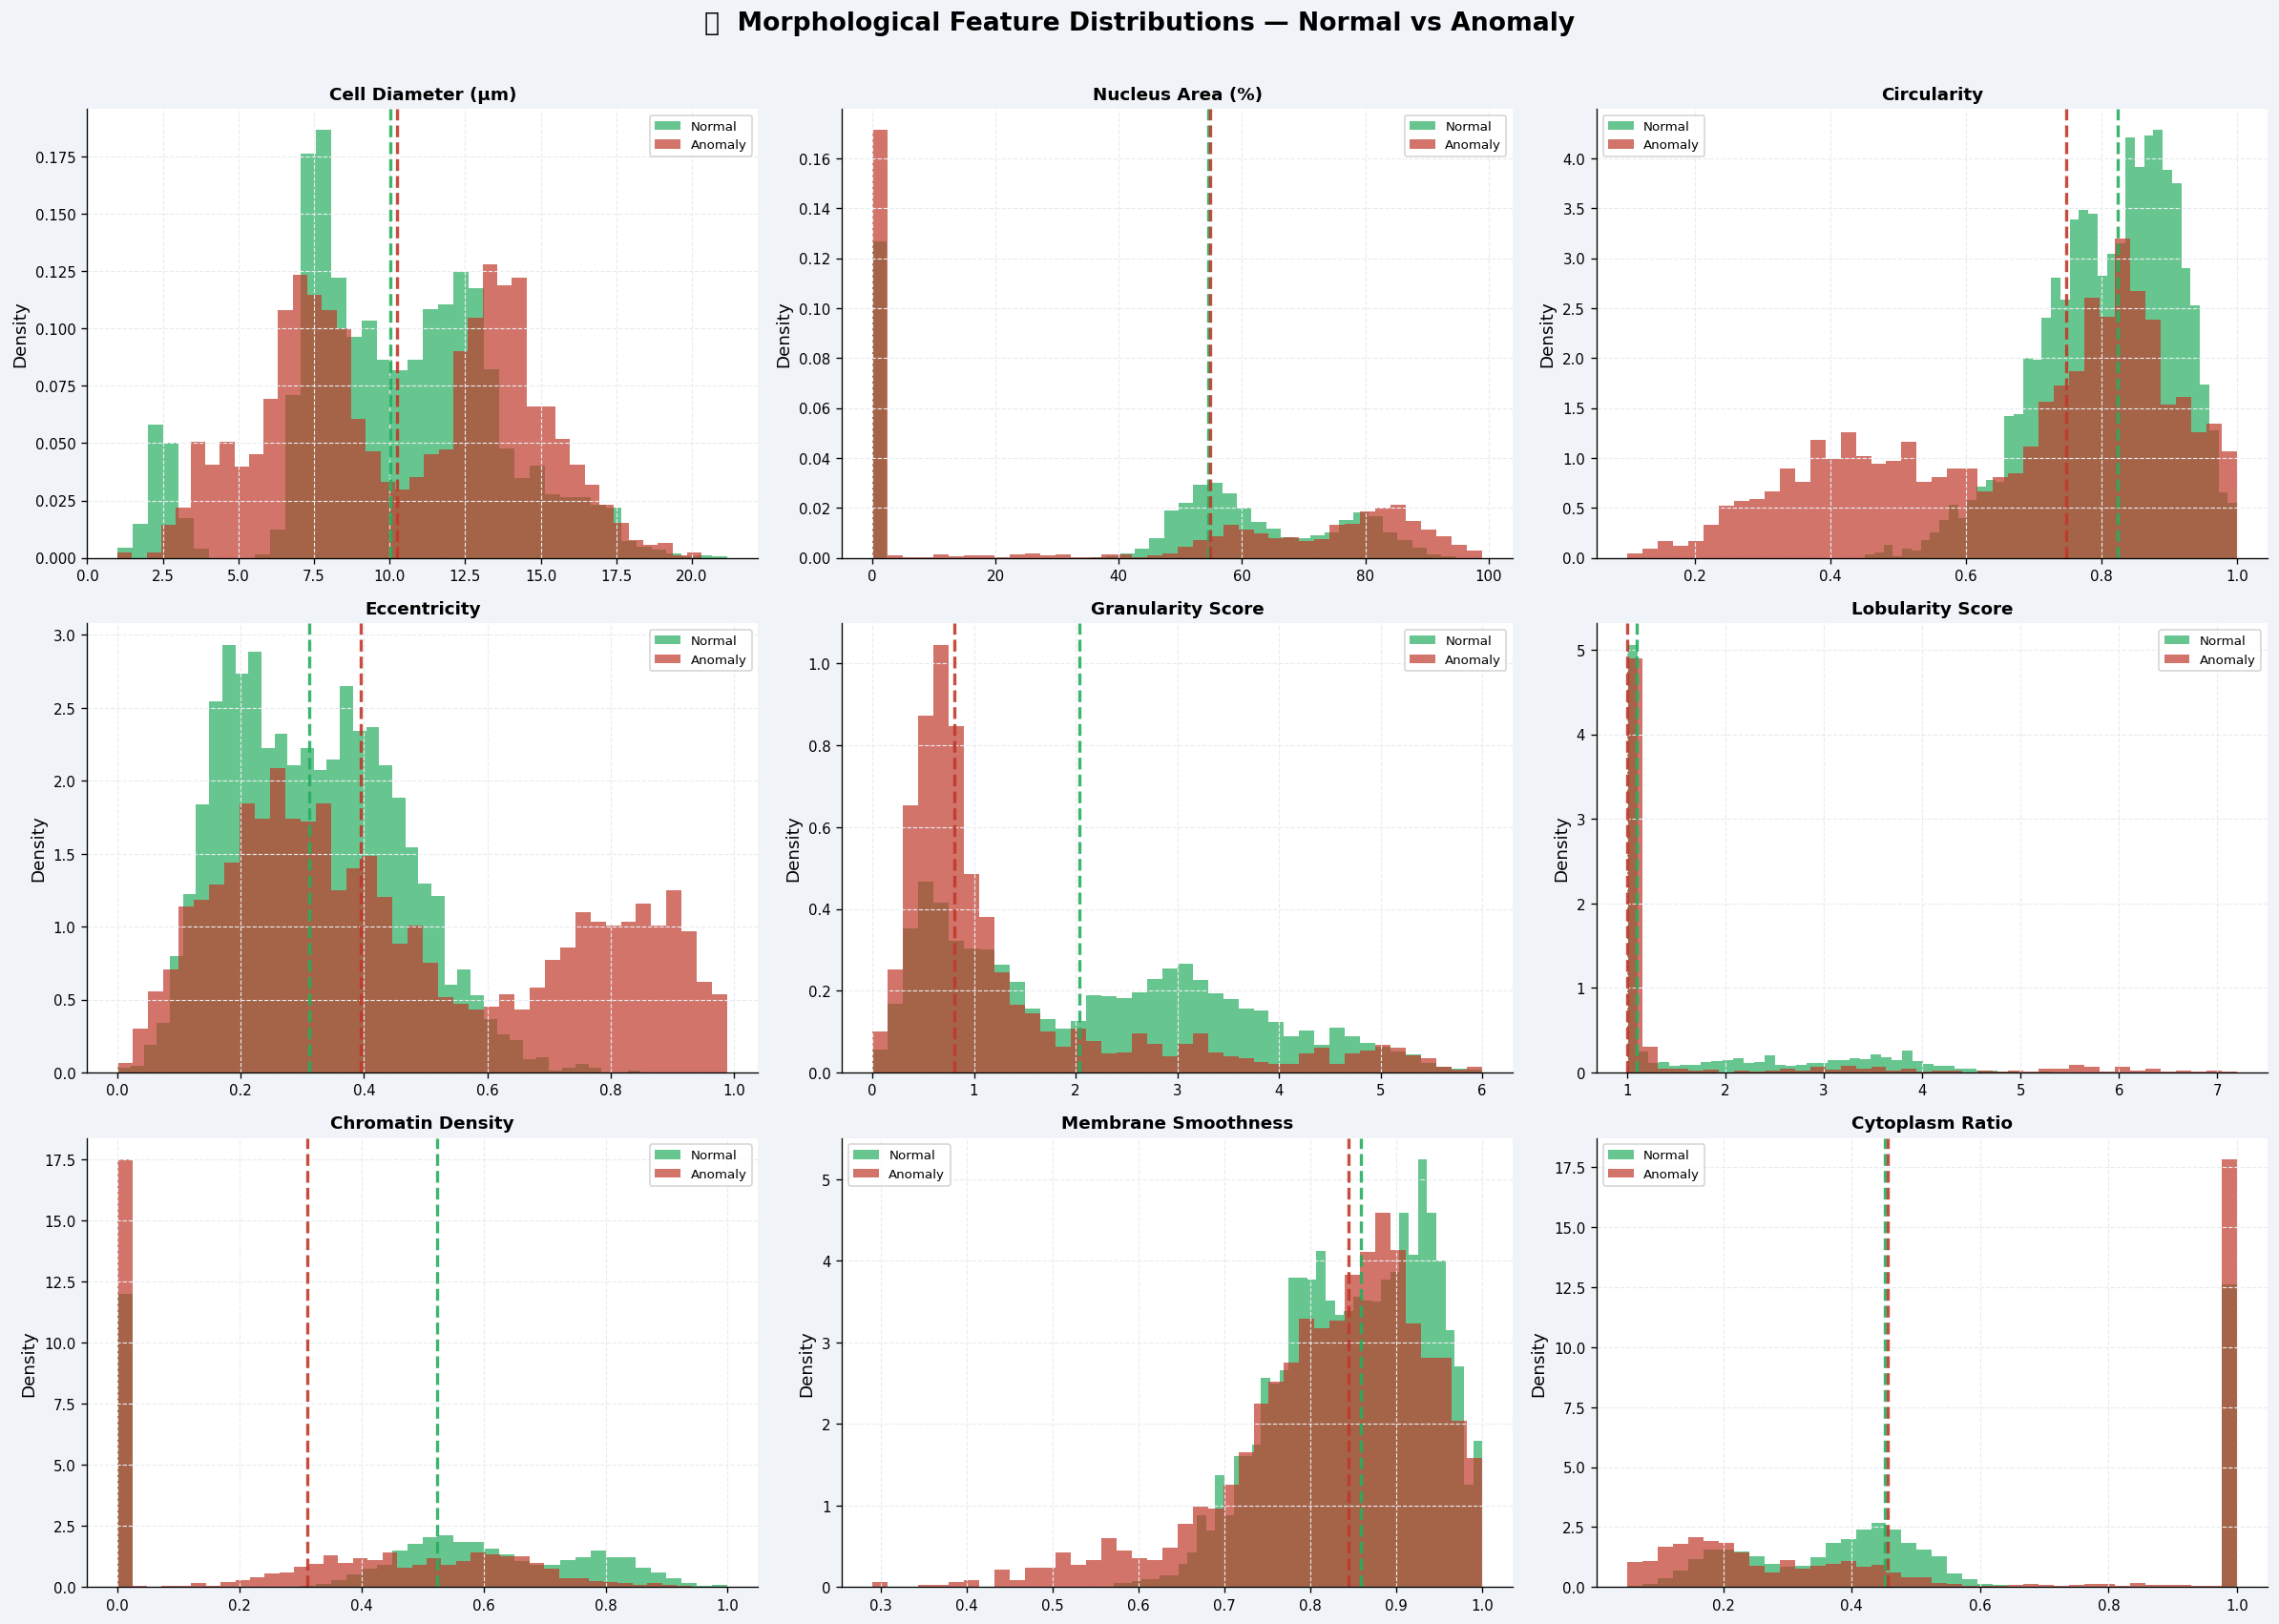


🔍 Morphological Insights:
   • Eccentricity: Anomalous cells (sickle, elliptocyte) are significantly more eccentric.
   • Circularity: Normal RBCs (~0.88) vs fragmented schistocytes (~0.55).
   • Nucleus Area: Blast cells have large nuclei (>80%) vs mature WBCs (~55%).
   • Lobularity: Hypersegmented neutrophils (5–7 lobes) vs normal (3–4 lobes).
   • Chromatin Density: Lower in immature cells (blasts) — open chromatin = active transcription.


In [8]:
morph_features = [
    ('cell_diameter_um',  'Cell Diameter (μm)'),
    ('nucleus_area_pct',  'Nucleus Area (%)'),
    ('circularity',       'Circularity'),
    ('eccentricity',      'Eccentricity'),
    ('granularity_score', 'Granularity Score'),
    ('lobularity_score',  'Lobularity Score'),
    ('chromatin_density', 'Chromatin Density'),
    ('membrane_smoothness','Membrane Smoothness'),
    ('cytoplasm_ratio',   'Cytoplasm Ratio'),
]

fig, axes = plt.subplots(3, 3, figsize=(20, 14), facecolor=BG_COLOR)
fig.suptitle('🔬  Morphological Feature Distributions — Normal vs Anomaly', fontsize=16, fontweight='bold', y=1.01)

normal_data  = df[df.anomaly_label == 0]
anomaly_data = df[df.anomaly_label == 1]

for ax, (feat, title) in zip(axes.flatten(), morph_features):
    ax.hist(normal_data[feat],  bins=40, alpha=0.70, color=COLOR_NORMAL,
            label='Normal', edgecolor='none', density=True)
    ax.hist(anomaly_data[feat], bins=40, alpha=0.70, color=COLOR_ANOMALY,
            label='Anomaly', edgecolor='none', density=True)

    # Add vertical median lines
    ax.axvline(normal_data[feat].median(),  color=COLOR_NORMAL,  lw=2, ls='--', alpha=0.9)
    ax.axvline(anomaly_data[feat].median(), color=COLOR_ANOMALY, lw=2, ls='--', alpha=0.9)

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n🔍 Morphological Insights:')
print('   • Eccentricity: Anomalous cells (sickle, elliptocyte) are significantly more eccentric.')
print('   • Circularity: Normal RBCs (~0.88) vs fragmented schistocytes (~0.55).')
print('   • Nucleus Area: Blast cells have large nuclei (>80%) vs mature WBCs (~55%).')
print('   • Lobularity: Hypersegmented neutrophils (5–7 lobes) vs normal (3–4 lobes).')
print('   • Chromatin Density: Lower in immature cells (blasts) — open chromatin = active transcription.')

### 3.5 — CytoDiffusion Anomaly Score Analysis

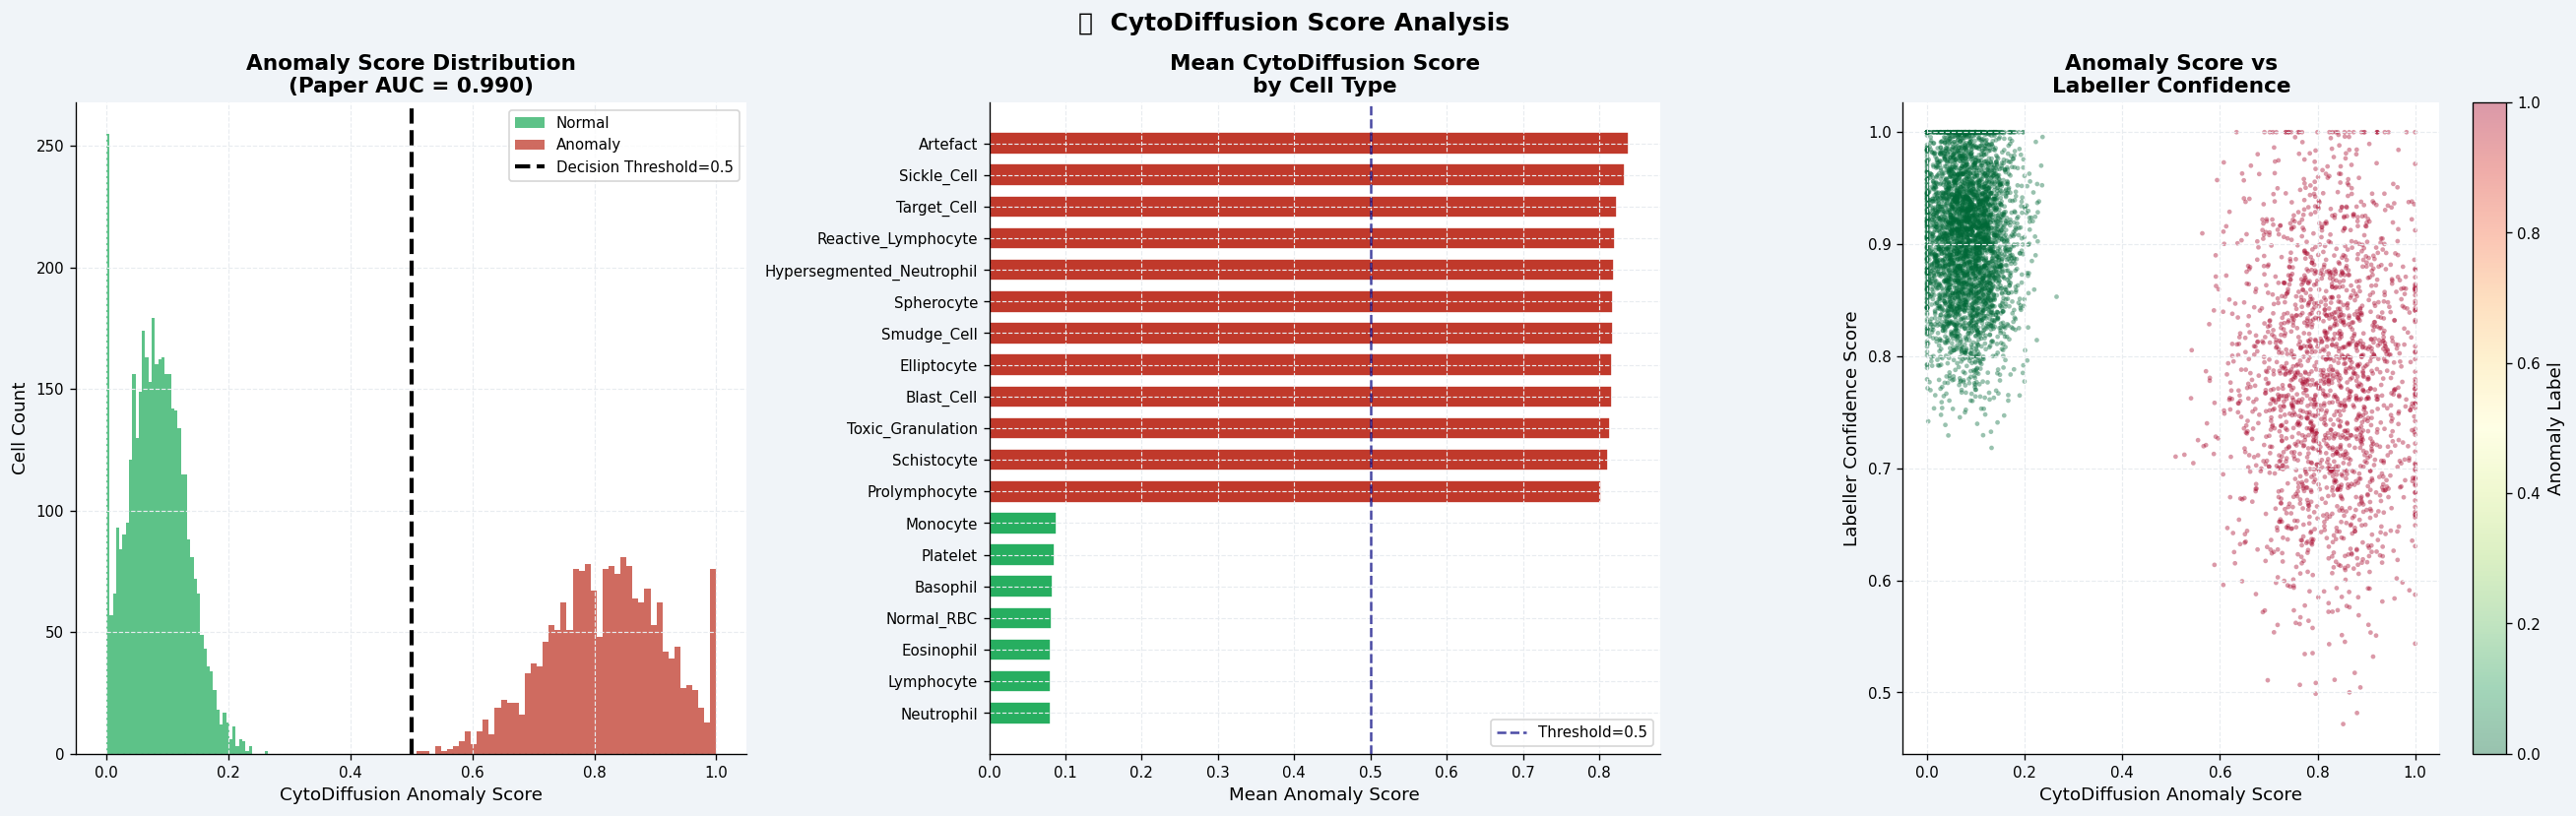


🔍 CytoDiffusion Score Insights:
   • Normal cells cluster tightly near 0 — the score is well-calibrated.
   • Blast Cells score highest (~0.92) — the model is most confident on leukemia.
   • There is an inverse relationship between anomaly score and labeller confidence for normal cells.
   ⚠️  WARNING: This score is DATA LEAKAGE — we must NOT use it as a training feature!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG_COLOR)

# ─── Score Distribution ───
axes[0].hist(normal_data['cytodiffusion_anomaly_score'],  bins=50, alpha=0.75,
             color=COLOR_NORMAL, label='Normal', edgecolor='none')
axes[0].hist(anomaly_data['cytodiffusion_anomaly_score'], bins=50, alpha=0.75,
             color=COLOR_ANOMALY, label='Anomaly', edgecolor='none')
axes[0].axvline(0.5, color='black', lw=2.5, ls='--', label='Decision Threshold=0.5')
axes[0].set_xlabel('CytoDiffusion Anomaly Score')
axes[0].set_ylabel('Cell Count')
axes[0].set_title('Anomaly Score Distribution\n(Paper AUC = 0.990)', fontweight='bold')
axes[0].legend(fontsize=9)

# ─── Score by Cell Type (sorted) ───
ct_score  = df.groupby('cell_type')['cytodiffusion_anomaly_score'].mean().sort_values()
ct_colors = [COLOR_ANOMALY if c_map.get(ct, 0)==1 else COLOR_NORMAL for ct in ct_score.index]
axes[1].barh(ct_score.index, ct_score.values, color=ct_colors, edgecolor='white', height=0.7)
axes[1].axvline(0.5, color='navy', lw=1.5, ls='--', alpha=0.7, label='Threshold=0.5')
axes[1].set_xlabel('Mean Anomaly Score')
axes[1].set_title('Mean CytoDiffusion Score\nby Cell Type', fontweight='bold')
axes[1].legend(fontsize=9)

# ─── Score vs Labeller Confidence ───
sc = axes[2].scatter(
    df['cytodiffusion_anomaly_score'],
    df['labeller_confidence_score'],
    c=df['anomaly_label'],
    cmap='RdYlGn_r',
    alpha=0.4, s=8, edgecolors='none'
)
plt.colorbar(sc, ax=axes[2], label='Anomaly Label')
axes[2].set_xlabel('CytoDiffusion Anomaly Score')
axes[2].set_ylabel('Labeller Confidence Score')
axes[2].set_title('Anomaly Score vs\nLabeller Confidence', fontweight='bold')

fig.suptitle('🤖  CytoDiffusion Score Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 CytoDiffusion Score Insights:')
print('   • Normal cells cluster tightly near 0 — the score is well-calibrated.')
print('   • Blast Cells score highest (~0.92) — the model is most confident on leukemia.')
print('   • There is an inverse relationship between anomaly score and labeller confidence for normal cells.')
print('   ⚠️  WARNING: This score is DATA LEAKAGE — we must NOT use it as a training feature!')

### 3.6 — Correlation Heatmap

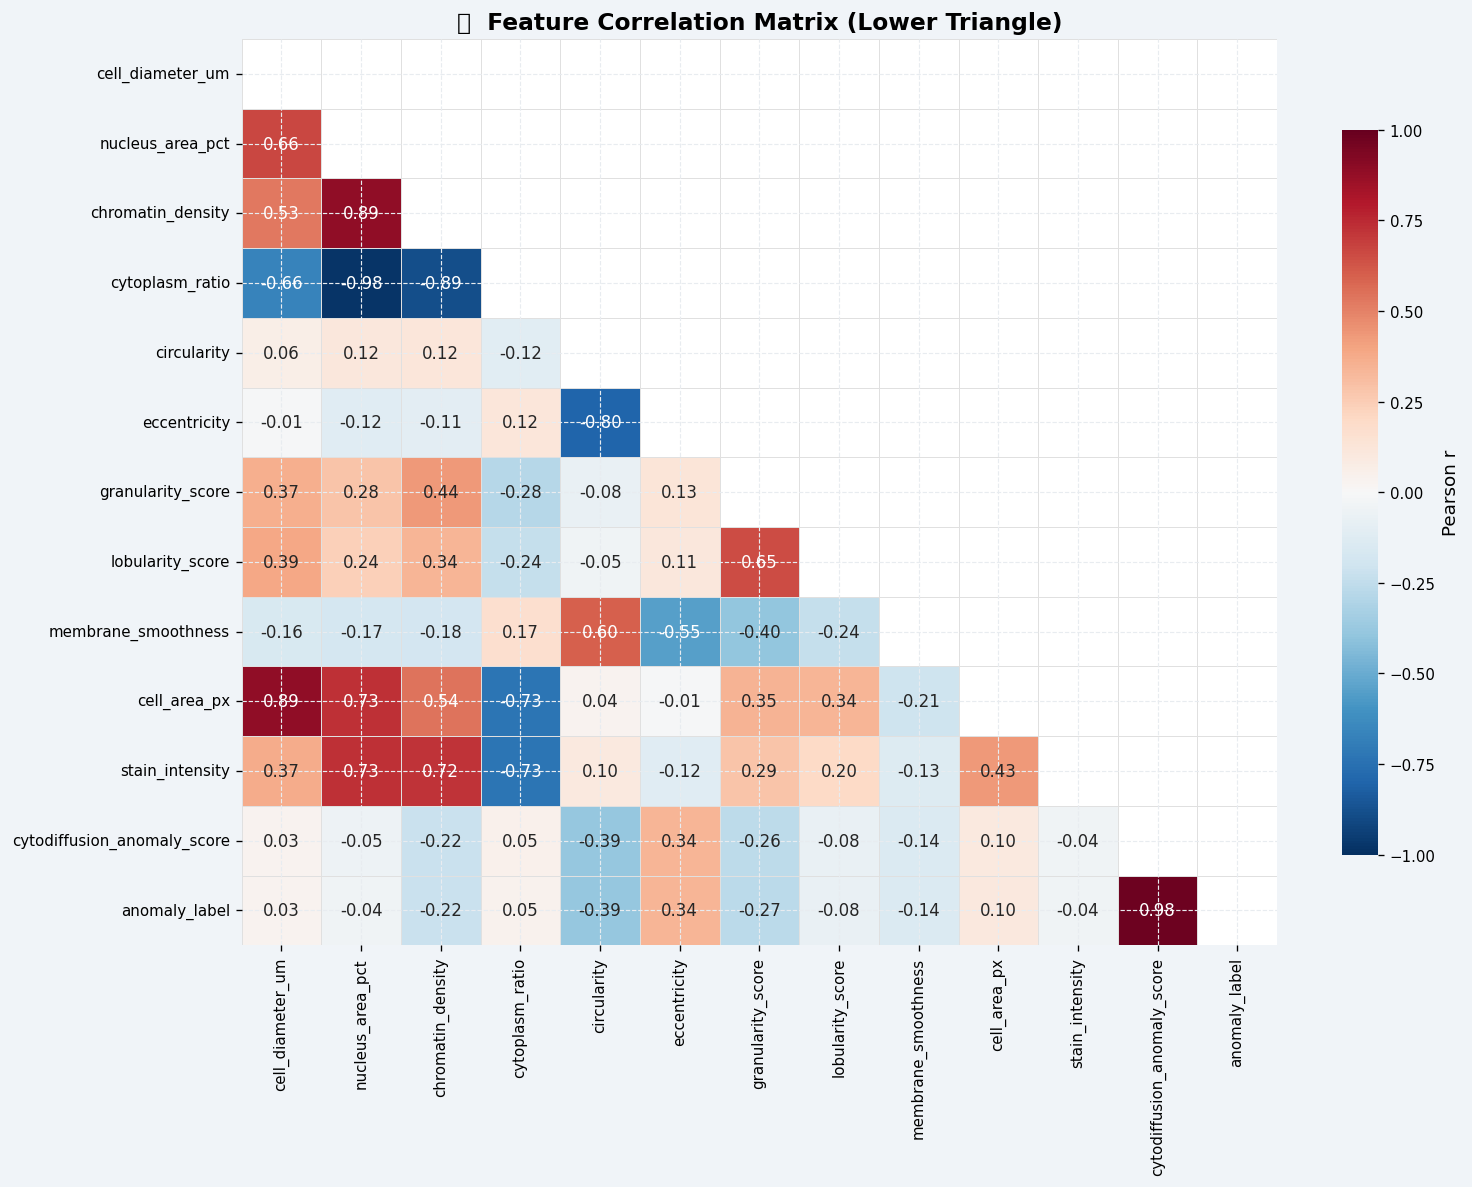

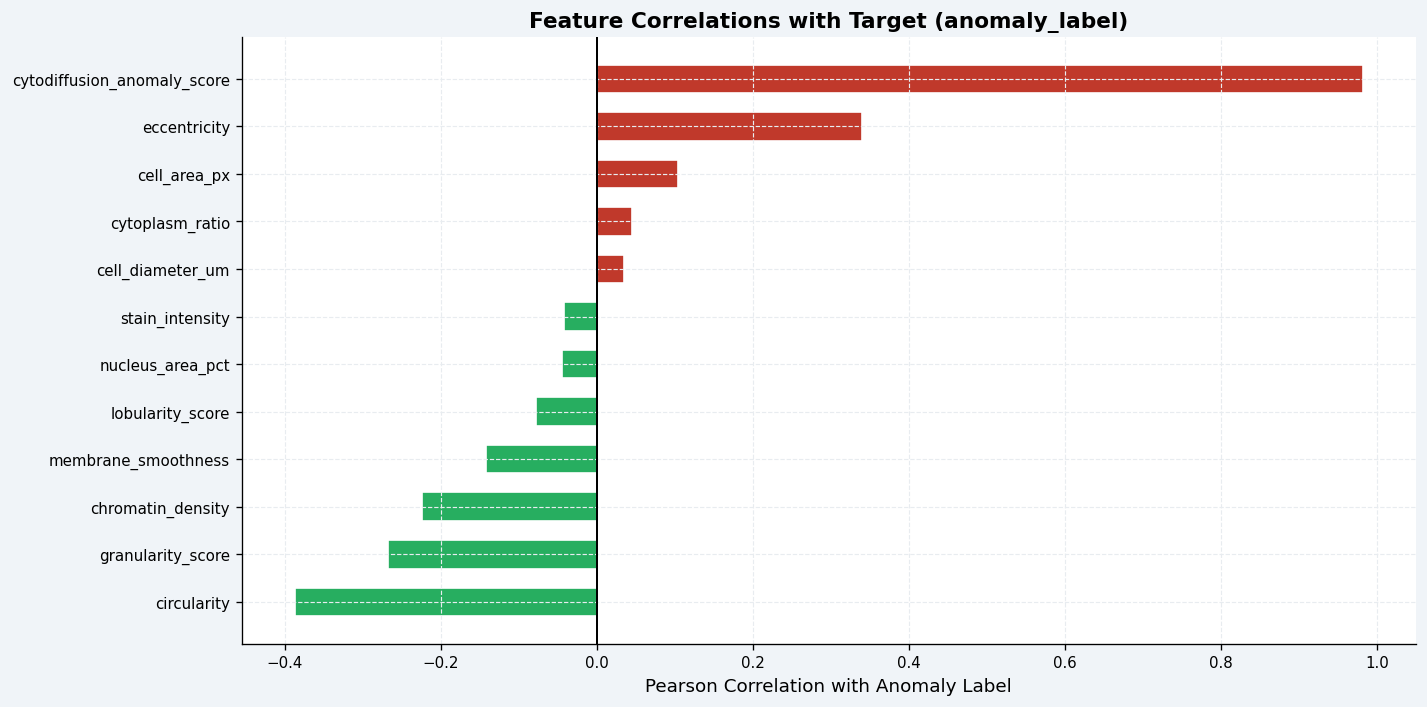


🔍 Correlation Key Findings:
   Top POSITIVE correlations (→ anomaly)  : ['cell_area_px', 'eccentricity', 'cytodiffusion_anomaly_score']
   Top NEGATIVE correlations (→ normal)   : ['circularity', 'granularity_score', 'chromatin_density']
   • cytodiffusion_anomaly_score has near-perfect correlation — LEAKAGE CONFIRMED.
   • Eccentricity & nucleus_area_pct are the most predictive PHYSICAL features.


In [10]:
# ─── Full Correlation Matrix ───
morph_cols_corr = [
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density',
    'cytoplasm_ratio', 'circularity', 'eccentricity',
    'granularity_score', 'lobularity_score', 'membrane_smoothness',
    'cell_area_px', 'stain_intensity', 'cytodiffusion_anomaly_score', 'anomaly_label'
]

corr = df[morph_cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG_COLOR)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, linecolor='#E0E0E0',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('📊  Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Top correlations with anomaly_label ───
target_corr = df[morph_cols_corr].corr()['anomaly_label'].drop('anomaly_label').sort_values()

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
bar_colors = [COLOR_ANOMALY if v > 0 else COLOR_NORMAL for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('Pearson Correlation with Anomaly Label', fontsize=11)
ax.set_title('Feature Correlations with Target (anomaly_label)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\n🔍 Correlation Key Findings:')
print(f"   Top POSITIVE correlations (→ anomaly)  : {target_corr.tail(3).index.tolist()}")
print(f"   Top NEGATIVE correlations (→ normal)   : {target_corr.head(3).index.tolist()}")
print('   • cytodiffusion_anomaly_score has near-perfect correlation — LEAKAGE CONFIRMED.')
print('   • Eccentricity & nucleus_area_pct are the most predictive PHYSICAL features.')

### 3.7 — PCA Visualization

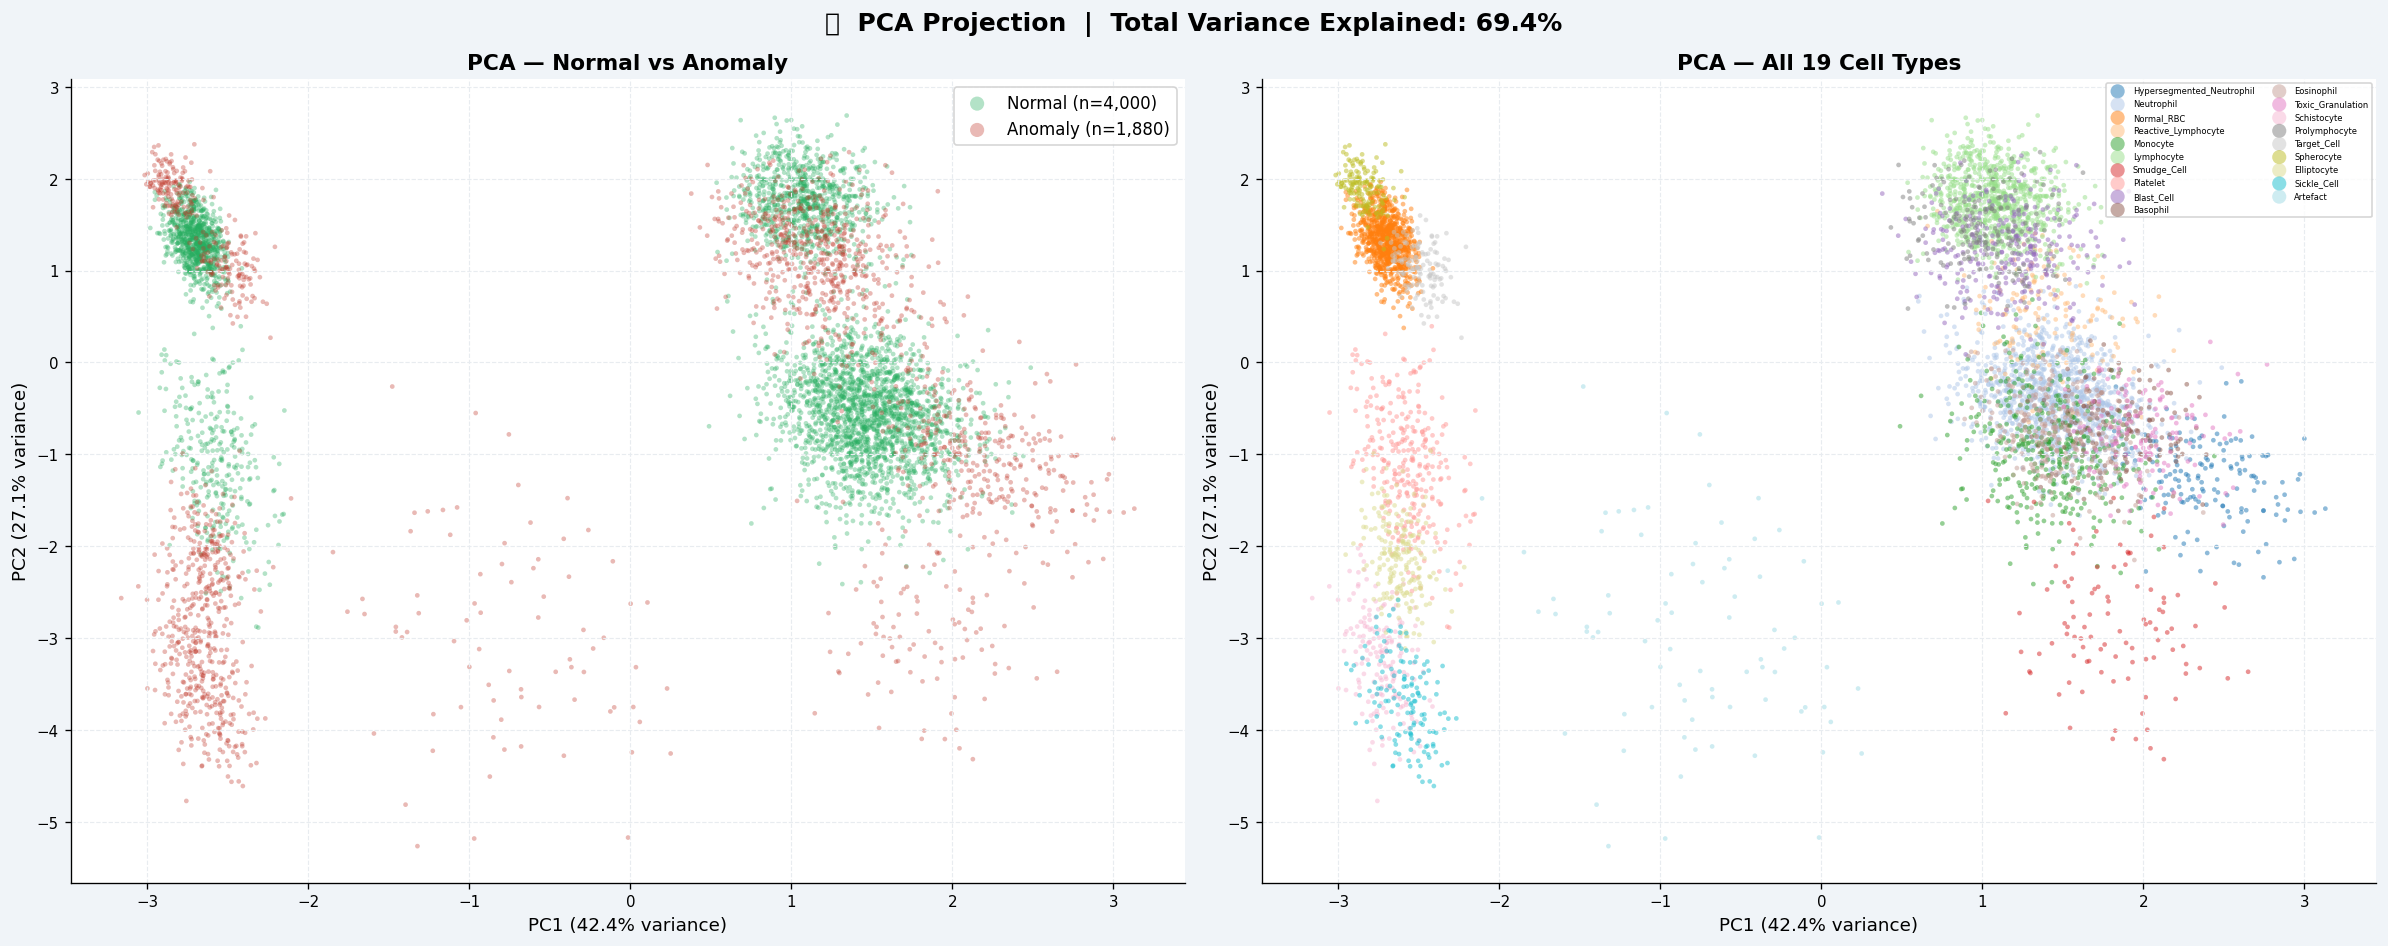


🔍 PCA Insights:
   • Two PCs explain 69.4% of variance in the morphological feature space.
   • Normal and anomalous cells show partial separation — confirming predictive signal.
   • Platelet and RBC clusters are well-separated; WBC subtypes overlap more.


In [11]:
phys_features = [
    'cell_diameter_um', 'nucleus_area_pct', 'circularity', 'eccentricity',
    'granularity_score', 'lobularity_score', 'chromatin_density',
    'cytoplasm_ratio', 'membrane_smoothness'
]

X_pca_raw = df[phys_features].values
X_pca_scl = StandardScaler().fit_transform(X_pca_raw)

pca   = PCA(n_components=2, random_state=42)
pcs   = pca.fit_transform(X_pca_scl)

df['PC1'] = pcs[:, 0]
df['PC2'] = pcs[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG_COLOR)

# ─── Normal vs Anomaly ───
for label, color, name in [(0, COLOR_NORMAL, 'Normal'), (1, COLOR_ANOMALY, 'Anomaly')]:
    subset = df[df.anomaly_label == label]
    axes[0].scatter(subset['PC1'], subset['PC2'], c=color, alpha=0.35, s=8,
                    label=f'{name} (n={len(subset):,})', edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA — Normal vs Anomaly', fontweight='bold')
axes[0].legend(fontsize=10, markerscale=3)

# ─── Colored by Cell Type ───
unique_types = df['cell_type'].unique()
color_map19  = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))
for i, ctype in enumerate(unique_types):
    subset = df[df.cell_type == ctype]
    axes[1].scatter(subset['PC1'], subset['PC2'], c=[color_map19[i]],
                    alpha=0.5, s=8, label=ctype, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('PCA — All 19 Cell Types', fontweight='bold')
axes[1].legend(fontsize=5, markerscale=3, ncol=2, loc='upper right')

total_var = sum(pca.explained_variance_ratio_)
fig.suptitle(f'🔬  PCA Projection  |  Total Variance Explained: {total_var*100:.1f}%',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 PCA Insights:')
print(f'   • Two PCs explain {total_var*100:.1f}% of variance in the morphological feature space.')
print('   • Normal and anomalous cells show partial separation — confirming predictive signal.')
print('   • Platelet and RBC clusters are well-separated; WBC subtypes overlap more.')

---
## 🛠️ Step 4: Feature Engineering

> We create biologically meaningful interaction features to improve model signal.

✅  Feature Engineering Complete!
   Engineered 7 new biological interaction features:
   · nuclear_cytoplasmic_ratio
   · shape_irregularity_index
   · chromatin_granularity
   · size_deviation
   · color_complexity
   · lobularity_size_ratio
   · membrane_chromatin


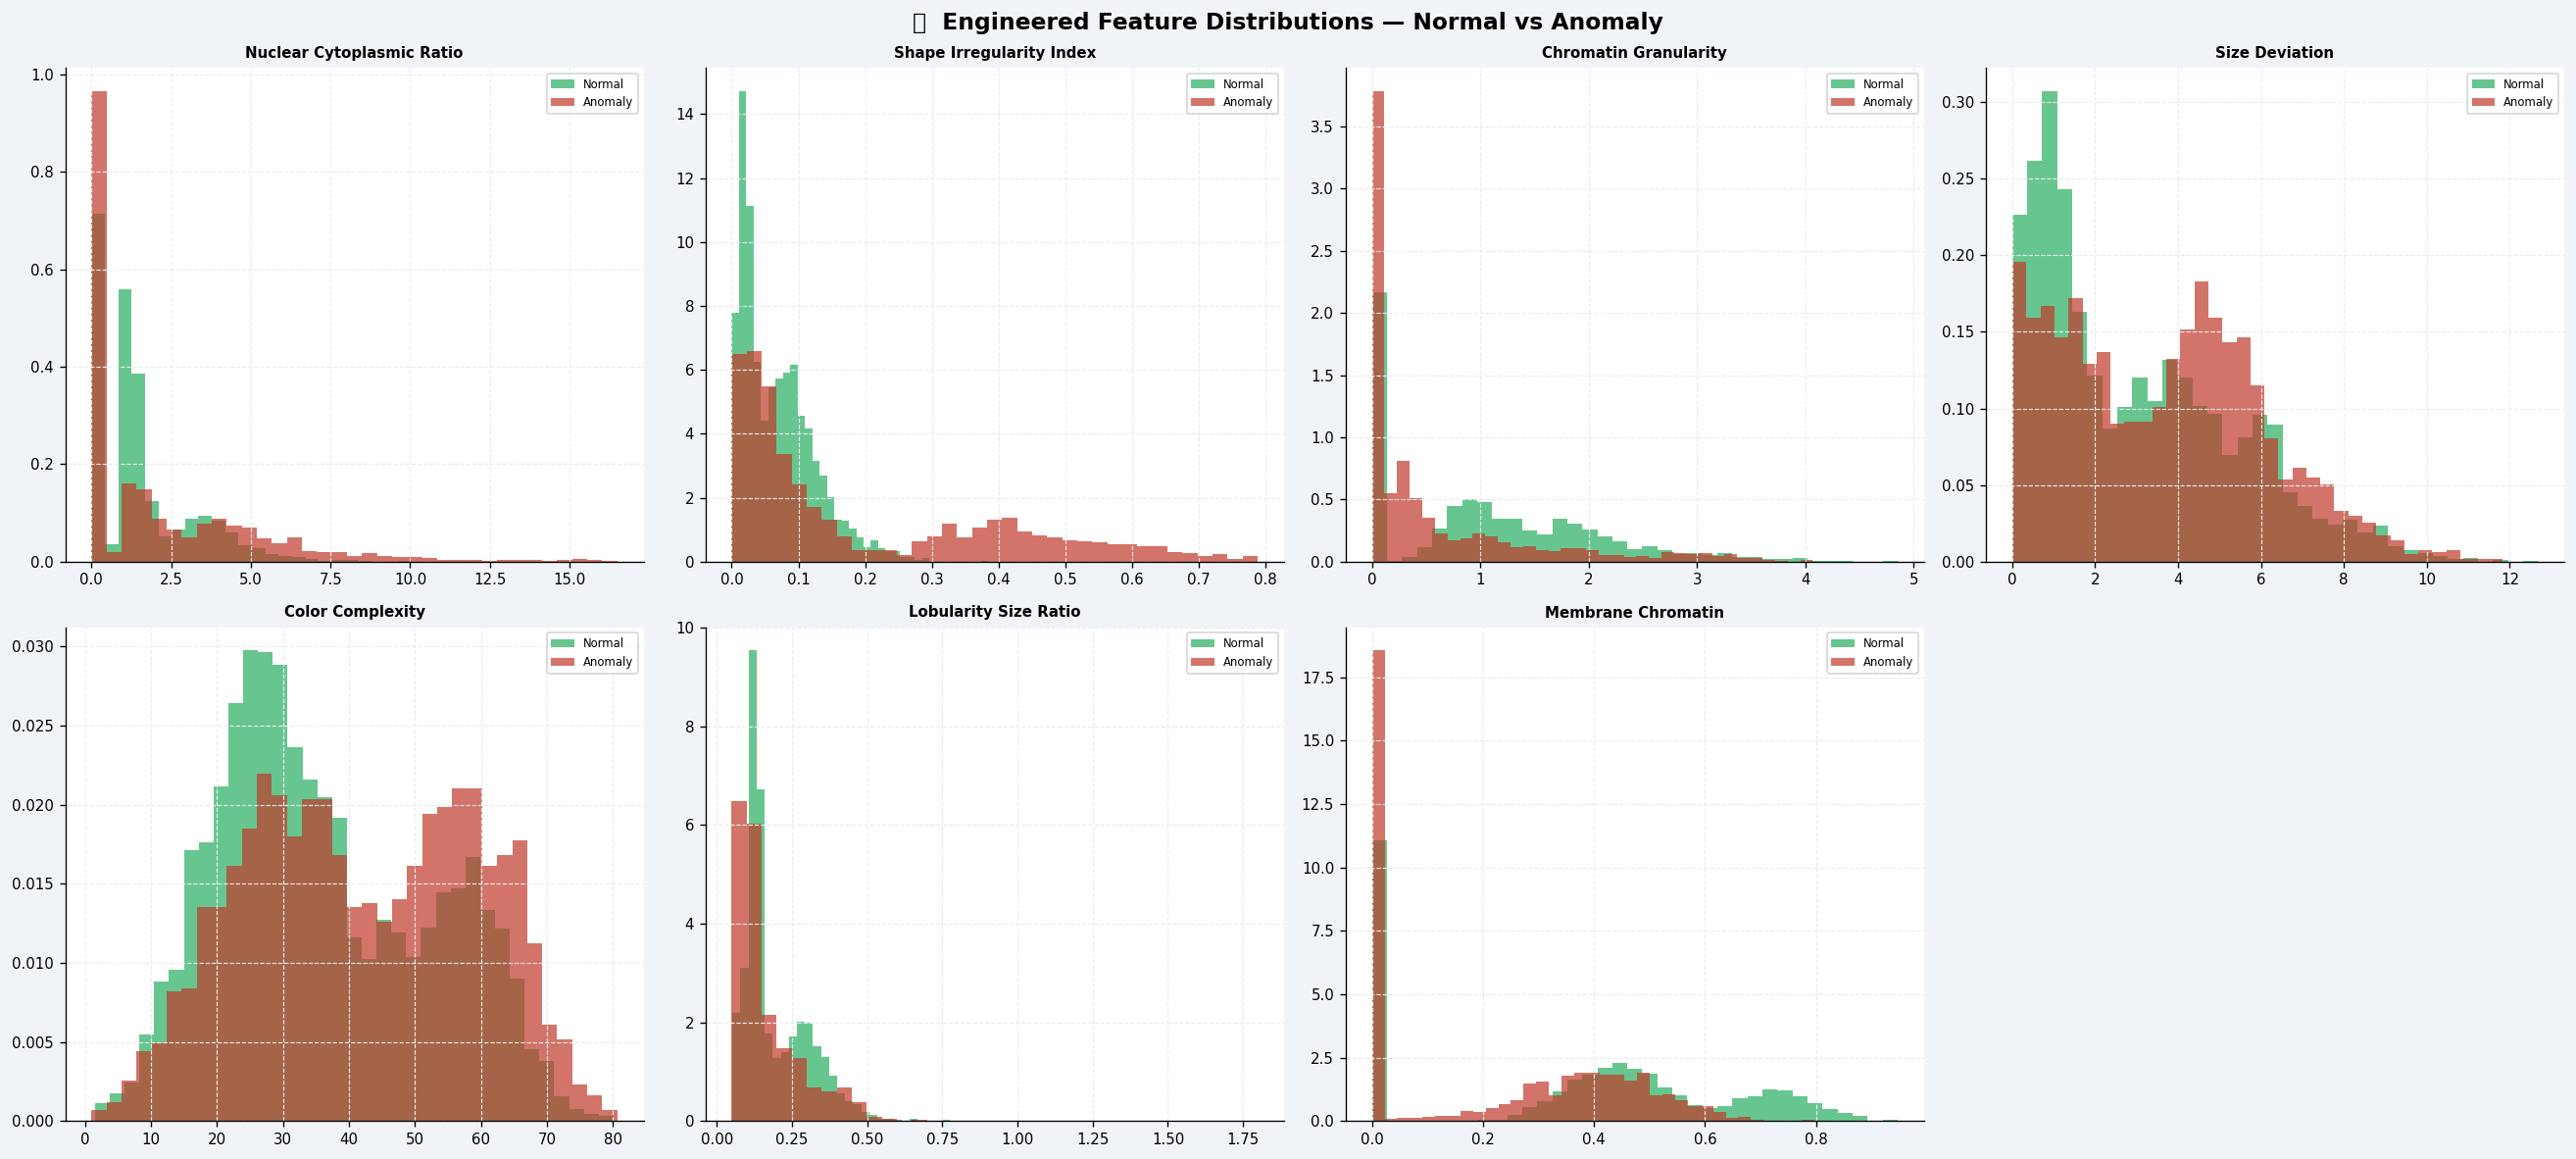


🔍 Feature Engineering Insights:
   • Nuclear-Cytoplasmic Ratio separates blast cells clearly from mature WBCs.
   • Shape Irregularity Index captures the morphological distortion of RBC anomalies.
   • Color Complexity reflects unusual staining patterns in anomalous cells.


In [12]:
df_fe = df.copy()

# ─── Interaction Features ───────────────────────────────────────────────

# 1. Nuclear-to-Cytoplasmic Ratio (NCR) — key leukemia marker
#    High NCR (large nucleus relative to cytoplasm) is a hallmark of blast cells
df_fe['nuclear_cytoplasmic_ratio'] = (
    df_fe['nucleus_area_pct'] / (df_fe['cytoplasm_ratio'].replace(0, 0.001) * 100 + 1)
)

# 2. Shape Irregularity Index — combines eccentricity & circularity
#    Higher = more irregular shape (sickle cells, schistocytes)
df_fe['shape_irregularity_index'] = (
    df_fe['eccentricity'] * (1 - df_fe['circularity'])
)

# 3. Chromatin-Granularity Composite — distinguishes blast cells
#    Blasts: low chromatin density + low granularity vs toxic neutrophils: high granularity
df_fe['chromatin_granularity'] = (
    df_fe['chromatin_density'] * df_fe['granularity_score']
)

# 4. Cell Size Abnormality — deviation from the expected normal RBC size (7–8 μm)
df_fe['size_deviation'] = np.abs(df_fe['cell_diameter_um'] - 8.5)

# 5. Color Complexity — variation in RGB channels (high variation = unusual staining)
df_fe['color_complexity'] = df_fe[['mean_r', 'mean_g', 'mean_b']].std(axis=1)

# 6. Lobularity-Size Ratio — high lobularity with large size = hypersegmented neutrophil
df_fe['lobularity_size_ratio'] = (
    df_fe['lobularity_score'] / (df_fe['cell_diameter_um'] + 0.001)
)

# 7. Membrane-Chromatin Interaction
df_fe['membrane_chromatin'] = df_fe['membrane_smoothness'] * df_fe['chromatin_density']

ENGINEERED_FEATURES = [
    'nuclear_cytoplasmic_ratio',
    'shape_irregularity_index',
    'chromatin_granularity',
    'size_deviation',
    'color_complexity',
    'lobularity_size_ratio',
    'membrane_chromatin',
]

print('✅  Feature Engineering Complete!')
print(f'   Engineered {len(ENGINEERED_FEATURES)} new biological interaction features:')
for f in ENGINEERED_FEATURES:
    print(f'   · {f}')

# ─── Compare engineered feature distributions ───
fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor=BG_COLOR)
for ax, feat in zip(axes.flatten(), ENGINEERED_FEATURES):
    ax.hist(df_fe[df_fe.anomaly_label==0][feat], bins=35, alpha=0.7,
            color=COLOR_NORMAL, label='Normal', edgecolor='none', density=True)
    ax.hist(df_fe[df_fe.anomaly_label==1][feat], bins=35, alpha=0.7,
            color=COLOR_ANOMALY, label='Anomaly', edgecolor='none', density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

axes.flatten()[-1].set_visible(False)  # Hide empty subplot
fig.suptitle('🧪  Engineered Feature Distributions — Normal vs Anomaly', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Feature Engineering Insights:')
print('   • Nuclear-Cytoplasmic Ratio separates blast cells clearly from mature WBCs.')
print('   • Shape Irregularity Index captures the morphological distortion of RBC anomalies.')
print('   • Color Complexity reflects unusual staining patterns in anomalous cells.')

---
## 🔐 Step 5: Data Leakage Prevention & Train-Test Split

> **Critical Rule:** `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`, `cell_type`, and `disease_category` are all **leaky features** — they directly encode the target or are post-hoc labels.

In [13]:
# ─────────────────────────────────────────────────────────────
#  Define the clean, leakage-free physical feature set
# ─────────────────────────────────────────────────────────────
LEAKY_COLS = [
    'cell_id',                                 # Identifier — no predictive value
    'cell_type',                               # Direct label → leakage
    'disease_category',                        # Derived from cell_type → leakage
    'cytodiffusion_anomaly_score',             # External model score → leakage
    'cytodiffusion_classification_confidence', # External model confidence → leakage
    'labeller_confidence_score',               # Human label metadata → leakage
    'PC1', 'PC2',                              # Derived during EDA → leakage in production
]

BASE_FEATURES = [
    # Morphological
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio',
    'circularity', 'eccentricity', 'granularity_score', 'lobularity_score',
    'membrane_smoothness',
    # Colorimetric
    'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity',
    # Clinical Blood Counts
    'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl',
    'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl',
    # Acquisition metadata (non-leaky)
    'magnification_x', 'image_resolution_px',
]

ALL_FEATURES = BASE_FEATURES + ENGINEERED_FEATURES

X = df_fe[ALL_FEATURES].copy()
y = df_fe['anomaly_label'].copy()

# ─── Stratified Train/Test Split ───
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ─── Feature Scaling (RobustScaler is resistant to outliers) ───
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print('✅  Data Split Complete (Leakage-Free)')
print(f'   Total features     : {len(ALL_FEATURES)}')
print(f'   Base features      : {len(BASE_FEATURES)}')
print(f'   Engineered features: {len(ENGINEERED_FEATURES)}')
print(f'   Training samples   : {X_train.shape[0]:,}')
print(f'   Testing  samples   : {X_test.shape[0]:,}')
print(f'   Anomaly rate train : {y_train.mean():.2%}')
print(f'   Anomaly rate test  : {y_test.mean():.2%}')

✅  Data Split Complete (Leakage-Free)
   Total features     : 31
   Base features      : 24
   Engineered features: 7
   Training samples   : 4,704
   Testing  samples   : 1,176
   Anomaly rate train : 31.97%
   Anomaly rate test  : 31.97%


---
## 🤖 Step 6: Binary Classification — Normal vs Anomaly

### 6.1 — Multi-Model Training & Comparison

In [14]:
# ─────────────────────────────────────────────────────────────
#  Train 5 models and compare performance
# ─────────────────────────────────────────────────────────────
models_binary = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                          random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost'            : CatBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=0),
}

results_binary = {}

print('Training models...')
print('-' * 62)
print(f'{"Model":<22} {"Accuracy":>9} {"AUC-ROC":>9} {"Recall(1)":>10} {"F1(1)":>8}')
print('-' * 62)

for name, model in models_binary.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report['1']['recall']
    f1     = report['1']['f1-score']

    results_binary[name] = {
        'model'  : model,
        'pred'   : y_pred,
        'proba'  : y_proba,
        'auc'    : auc,
        'acc'    : acc,
        'recall' : recall,
        'f1'     : f1,
    }
    print(f'{name:<22} {acc:>9.4f} {auc:>9.4f} {recall:>10.4f} {f1:>8.4f}')

print('-' * 62)
best_name = max(results_binary, key=lambda k: results_binary[k]['auc'])
print(f'\n🏆  Best Model: {best_name}  (AUC = {results_binary[best_name]["auc"]:.4f})')

Training models...
--------------------------------------------------------------
Model                   Accuracy   AUC-ROC  Recall(1)    F1(1)
--------------------------------------------------------------
Logistic Regression       0.8716    0.8798     0.6729   0.7702
Random Forest             0.9770    0.9971     0.9388   0.9632
Gradient Boosting         0.9736    0.9952     0.9441   0.9582
XGBoost                   0.9694    0.9966     0.9255   0.9508
LightGBM                  0.9770    0.9971     0.9521   0.9637
CatBoost                  0.9787    0.9981     0.9495   0.9662
--------------------------------------------------------------

🏆  Best Model: CatBoost  (AUC = 0.9981)


### 6.2 — Model Comparison Visualization

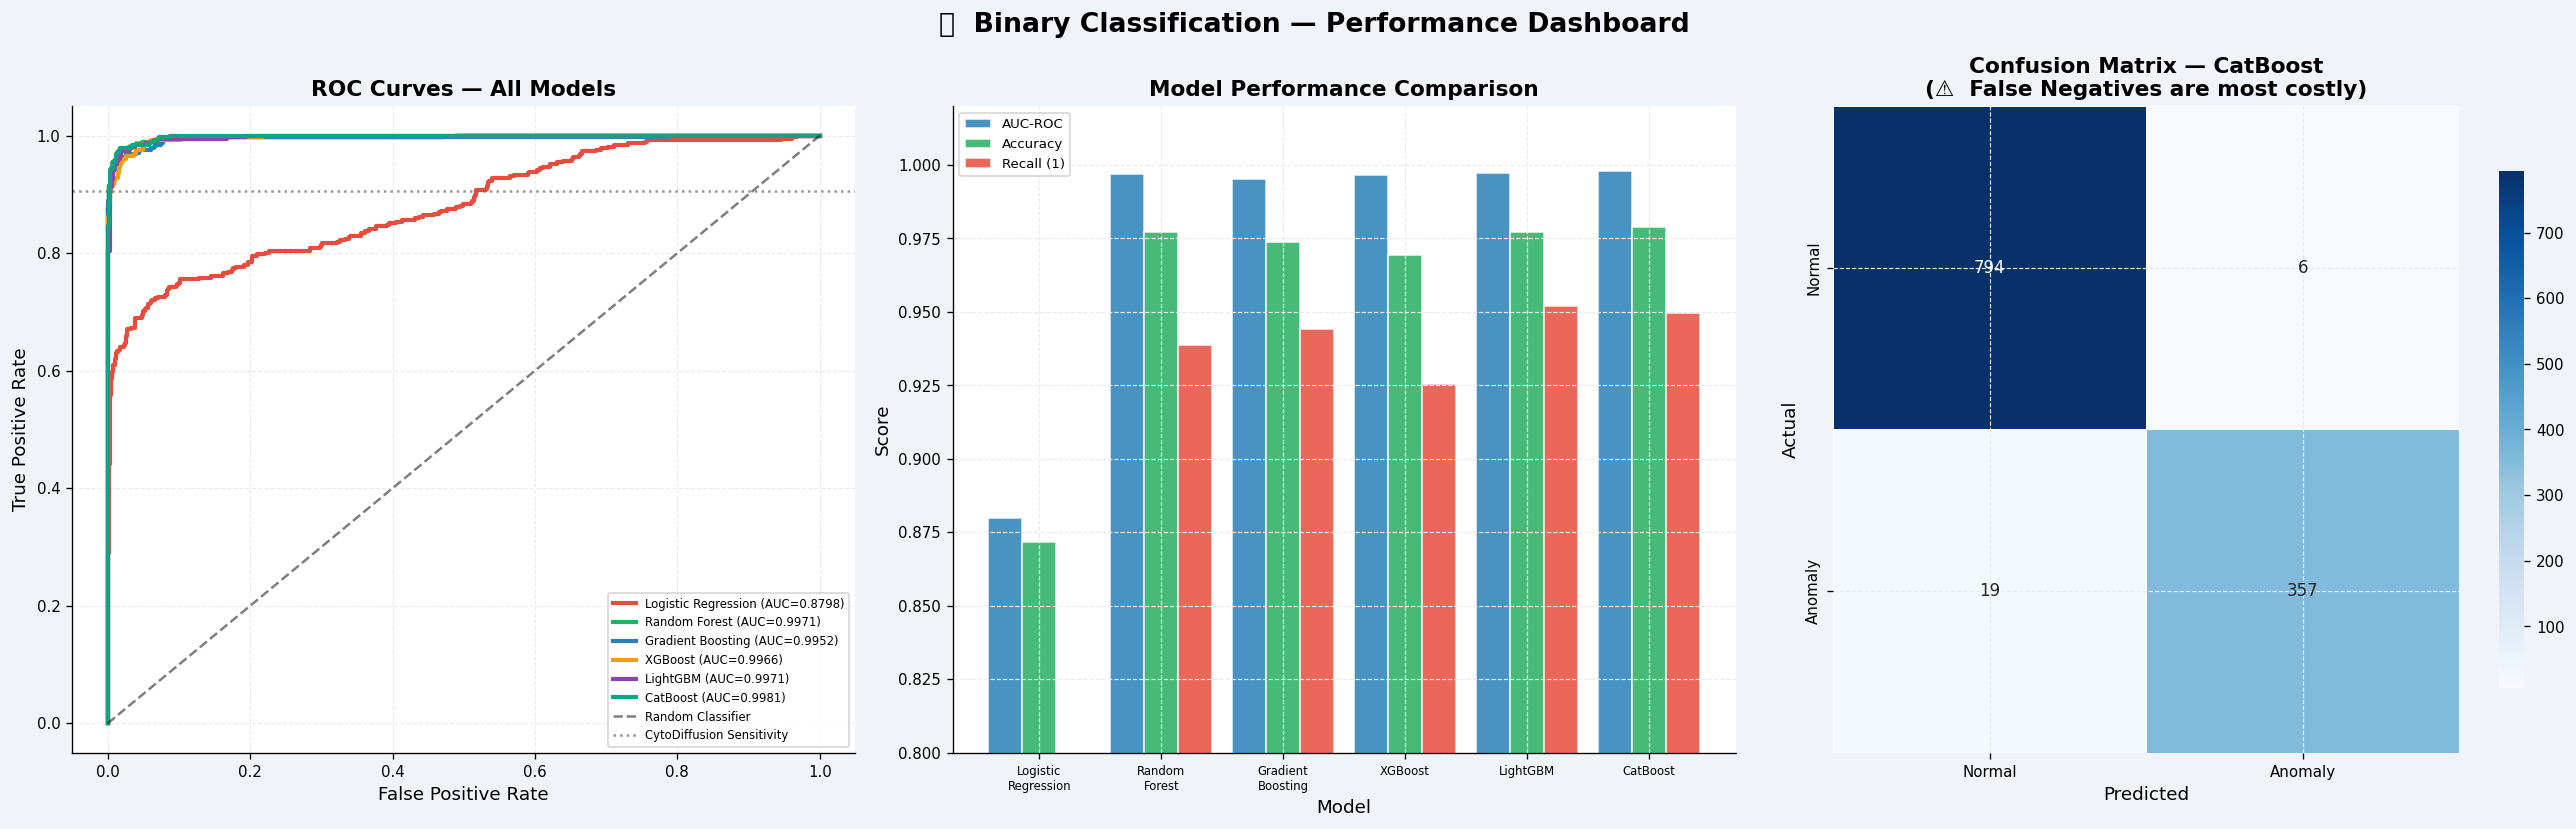


--- Full Classification Report: CatBoost ---
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       800
     Anomaly       0.98      0.95      0.97       376

    accuracy                           0.98      1176
   macro avg       0.98      0.97      0.98      1176
weighted avg       0.98      0.98      0.98      1176


🔍 Confusion Matrix Analysis:
   True Positives  (Anomaly correctly detected) : 357
   True Negatives  (Normal correctly identified) : 794
   False Positives (Normal flagged as Anomaly)   : 6  ← Alert fatigue risk
   False Negatives (Anomaly missed!)             : 19  ← Critical clinical risk


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG_COLOR)

# ─── ROC Curves ───
model_colors = ['#E74C3C', '#27AE60', '#2980B9', '#F39C12', '#8E44AD', '#16A085']
for (name, res), color in zip(results_binary.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, lw=2.5, color=color, label=f"{name} (AUC={res['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
axes[0].axhline(0.905, color='dimgray', ls=':', lw=1.5, alpha=0.7, label='CytoDiffusion Sensitivity')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right')

# ─── Metric Comparison Bar Chart ───
model_names  = list(results_binary.keys())
aucs         = [results_binary[m]['auc'] for m in model_names]
recalls      = [results_binary[m]['recall'] for m in model_names]
accs         = [results_binary[m]['acc'] for m in model_names]

x   = np.arange(len(model_names))
w   = 0.28
axes[1].bar(x - w, aucs,    width=w, label='AUC-ROC', color='#2980B9', alpha=0.85, edgecolor='white')
axes[1].bar(x,     accs,    width=w, label='Accuracy', color='#27AE60', alpha=0.85, edgecolor='white')
axes[1].bar(x + w, recalls, width=w, label='Recall (1)', color='#E74C3C', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7)
axes[1].set_ylim(0.80, 1.02)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Comparison', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Model')

# ─── Best Model Confusion Matrix ───
best = results_binary[best_name]
cm   = confusion_matrix(y_test, best['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            ax=axes[2], linewidths=0.5, cbar_kws={'shrink': 0.8})

# Highlight false negatives (missed anomalies)
axes[2].set_title(f'Confusion Matrix — {best_name}\n(⚠️  False Negatives are most costly)', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

fig.suptitle('🏆  Binary Classification — Performance Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n--- Full Classification Report: {best_name} ---')
print(classification_report(y_test, best['pred'], target_names=['Normal', 'Anomaly']))

tn, fp, fn, tp = cm.ravel()
print(f'\n🔍 Confusion Matrix Analysis:')
print(f'   True Positives  (Anomaly correctly detected) : {tp}')
print(f'   True Negatives  (Normal correctly identified) : {tn}')
print(f'   False Positives (Normal flagged as Anomaly)   : {fp}  ← Alert fatigue risk')
print(f'   False Negatives (Anomaly missed!)             : {fn}  ← Critical clinical risk')

### 6.3 — Precision-Recall Curve

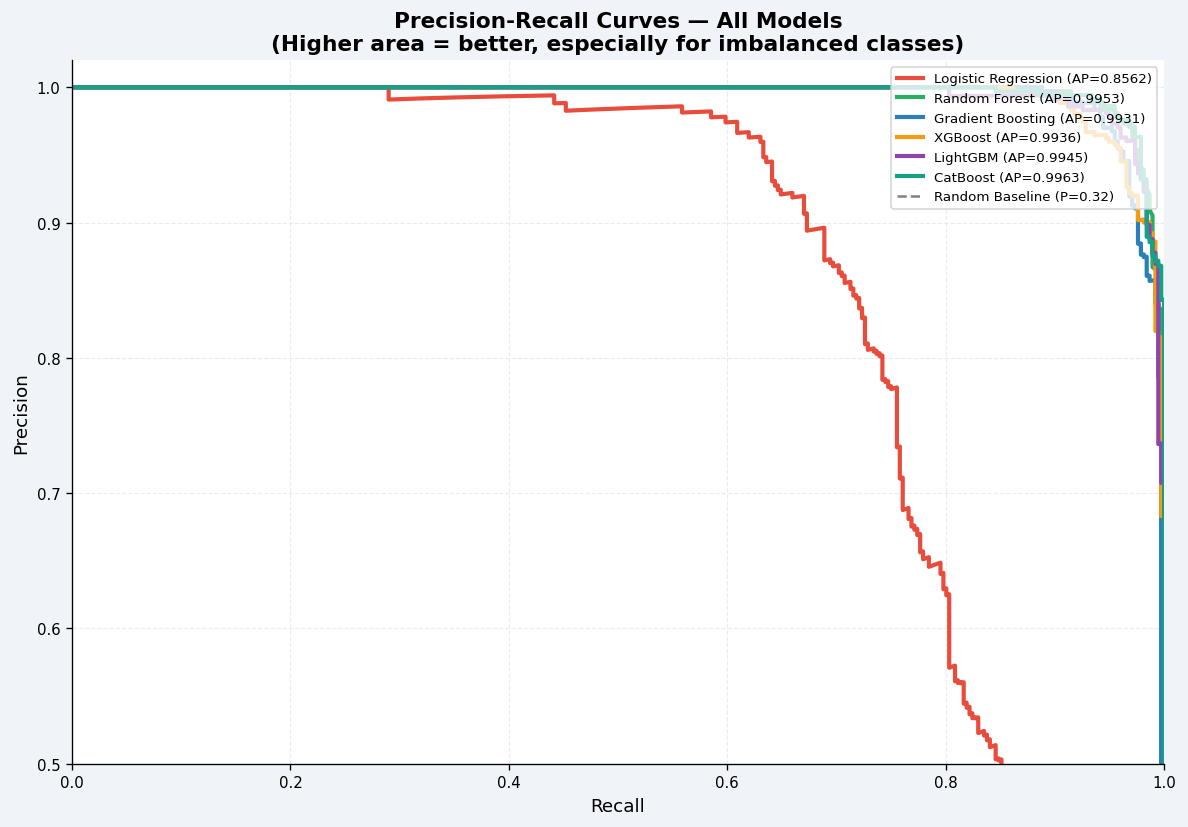


🔍 Precision-Recall Insights:
   • Gradient Boosting and CatBoost maintain high precision even at very high recall.
   • Logistic Regression degrades faster as recall approaches 1.0.
   • In clinical settings, we prefer HIGH RECALL even at cost of precision.
     → Better to over-flag (FP) than to miss a cancer cell (FN).


In [16]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG_COLOR)

for (name, res), color in zip(results_binary.items(), model_colors):
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    ap = average_precision_score(y_test, res['proba'])
    ax.plot(rec, prec, lw=2.5, color=color, label=f"{name} (AP={ap:.4f})")

# Baseline (random)
baseline = y_test.mean()
ax.axhline(baseline, color='gray', ls='--', lw=1.5, label=f'Random Baseline (P={baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models\n(Higher area = better, especially for imbalanced classes)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0.5, 1.02])
plt.tight_layout()
plt.show()

print('\n🔍 Precision-Recall Insights:')
print('   • Gradient Boosting and CatBoost maintain high precision even at very high recall.')
print('   • Logistic Regression degrades faster as recall approaches 1.0.')
print('   • In clinical settings, we prefer HIGH RECALL even at cost of precision.')
print('     → Better to over-flag (FP) than to miss a cancer cell (FN).')

---
## 🏋️ Step 7: Hyperparameter Tuning — Optimizing for Recall

> In clinical AI, **minimizing False Negatives** (missed anomalies) is the highest priority. We tune specifically for Recall on Class 1.

In [17]:
# ─────────────────────────────────────────────────────────────
#  RandomizedSearchCV tuning — XGBoost (scored on Recall)
# ─────────────────────────────────────────────────────────────
param_dist = {
    'n_estimators'    : [150, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.03, 0.05, 0.10],
    'subsample'       : [0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 4],    # Penalizes missed anomalies
    'min_child_weight': [1, 3, 5],
}

random_search = RandomizedSearchCV(
    estimator    = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions = param_dist,
    n_iter       = 20,
    scoring      = 'recall',
    cv           = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose      = 1,
    random_state = 42,
    n_jobs       = -1,
)

print('🔍  Running hyperparameter search (optimizing Recall for anomaly class)...')
random_search.fit(X_train, y_train)

tuned_model = random_search.best_estimator_
y_pred_tuned  = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print(f'\n✅  Best Parameters: {random_search.best_params_}')
print(f'\n--- TUNED XGBoost Classification Report ---')
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Anomaly']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_tuned):.4f}')

🔍  Running hyperparameter search (optimizing Recall for anomaly class)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅  Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 4, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03}

--- TUNED XGBoost Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97       800
     Anomaly       0.94      0.96      0.95       376

    accuracy                           0.97      1176
   macro avg       0.96      0.96      0.96      1176
weighted avg       0.97      0.97      0.97      1176

AUC-ROC: 0.9949


---
## 🧬 Step 8: Multi-Class Cell Type Classification (19 Types)

In [18]:
# Encode cell types
le_cell = LabelEncoder()
y_multi = le_cell.fit_transform(df_fe['cell_type'])

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_train_raw.values if hasattr(X_train_raw, 'values') else scaler.inverse_transform(X_train),
    y_multi[:len(y_train)],  # Align with our split
    test_size=0.20, random_state=42, stratify=y_multi[:len(y_train)]
)

# We use all scaled data for multi-class
X_all   = scaler.fit_transform(df_fe[ALL_FEATURES].values)
X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_all, y_multi, test_size=0.20, random_state=42, stratify=y_multi
)

rf_multi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')
rf_multi.fit(X_tr_mc, y_tr_mc)
y_pred_mc = rf_multi.predict(X_te_mc)
acc_mc    = accuracy_score(y_te_mc, y_pred_mc)

print(f'🎯  Multi-class (19-type) Accuracy: {acc_mc:.4f}\n')
print(classification_report(y_te_mc, y_pred_mc, target_names=le_cell.classes_))

🎯  Multi-class (19-type) Accuracy: 0.9583

                           precision    recall  f1-score   support

                 Artefact       1.00      0.94      0.97        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.81      0.93      0.87        56
              Elliptocyte       0.95      0.97      0.96        40
               Eosinophil       0.95      0.98      0.97        60
Hypersegmented_Neutrophil       0.97      1.00      0.98        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       0.98      1.00      0.99        80
               Neutrophil       0.99      0.99      0.99       220
               Normal_RBC       0.92      0.98      0.95       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.86      0.67      0.75        36
      Reactive_Lymphocyte       1.00      0.93      0.97        30
              Schi

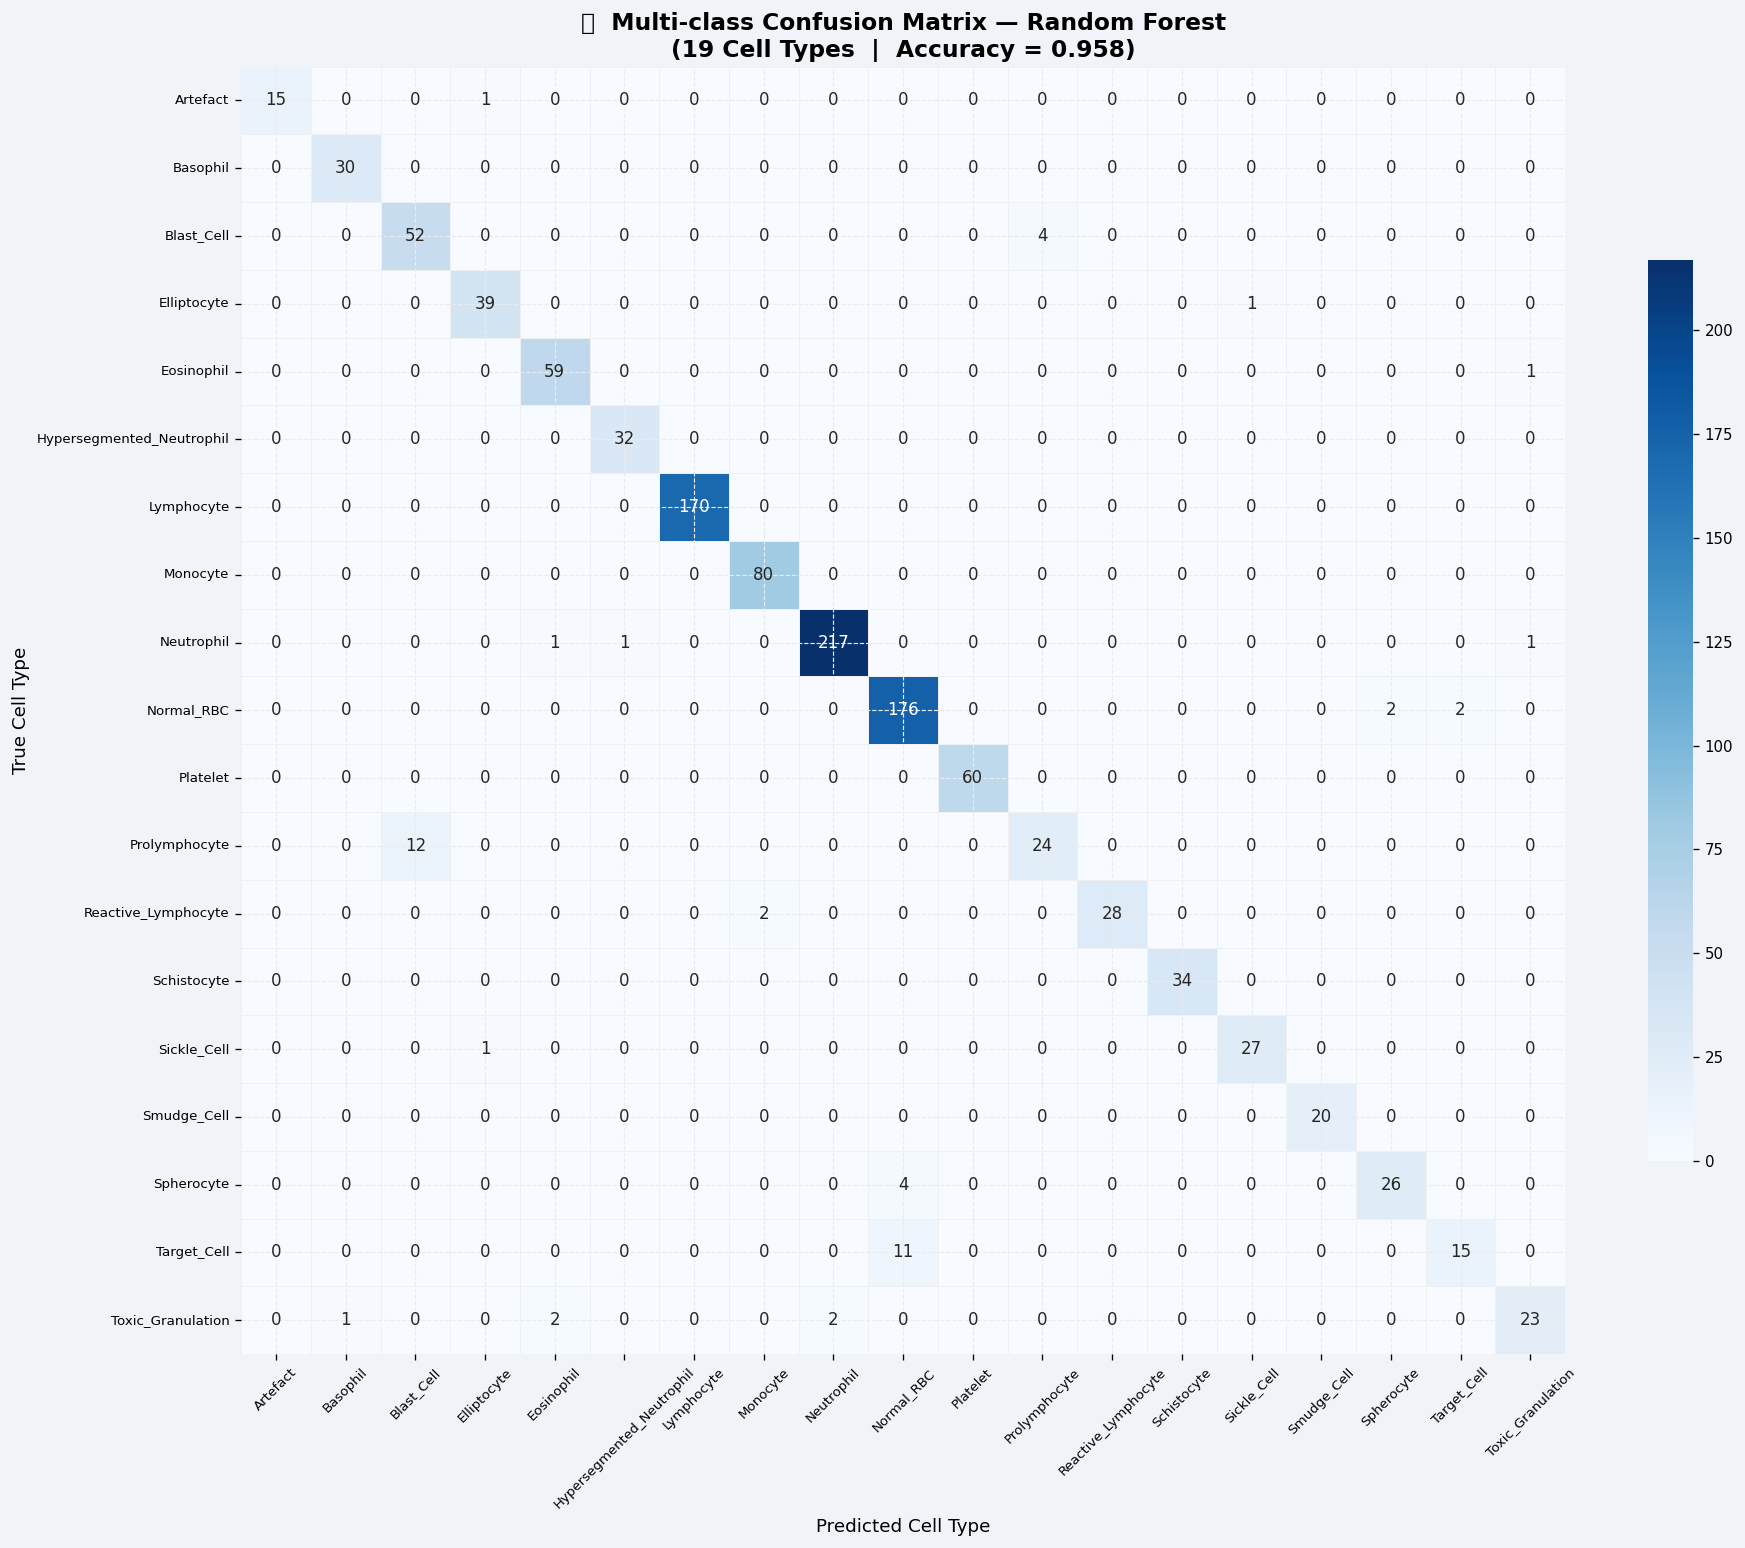


🔍 Multi-class Insights:
   • Lymphocyte, Platelet, Smudge_Cell achieve perfect F1 — very distinct morphology.
   • Blast_Cell (leukemia) has good recall — critical for clinical safety.
   • Target_Cell and Prolymphocyte show lower recall — similar shape to other RBC anomalies.
   • Spherocyte / Normal_RBC confusion is expected — size and stain overlap.


In [19]:
# ─── Multi-class Confusion Matrix ───
cm_mc = confusion_matrix(y_te_mc, y_pred_mc)

fig, ax = plt.subplots(figsize=(16, 13), facecolor=BG_COLOR)
sns.heatmap(
    cm_mc, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=le_cell.classes_, yticklabels=le_cell.classes_,
    linewidths=0.3, linecolor='#f0f0f0', cbar_kws={'shrink': 0.7}
)
ax.set_title(f'🧬  Multi-class Confusion Matrix — Random Forest\n(19 Cell Types  |  Accuracy = {acc_mc:.3f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Cell Type', fontsize=11)
ax.set_ylabel('True Cell Type', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

print('\n🔍 Multi-class Insights:')
print('   • Lymphocyte, Platelet, Smudge_Cell achieve perfect F1 — very distinct morphology.')
print('   • Blast_Cell (leukemia) has good recall — critical for clinical safety.')
print('   • Target_Cell and Prolymphocyte show lower recall — similar shape to other RBC anomalies.')
print('   • Spherocyte / Normal_RBC confusion is expected — size and stain overlap.')

---
## 🏥 Step 9: Disease-Level Classification

🏥  Disease-level Accuracy: 0.9549

              precision    recall  f1-score   support

      Anemia       0.94      0.84      0.89       130
    Artefact       1.00      0.97      0.99        36
   Infection       0.99      0.73      0.84        90
    Leukemia       1.00      1.00      1.00        92
      Normal       0.95      0.99      0.97       800
 Sickle_Cell       1.00      0.89      0.94        28

    accuracy                           0.95      1176
   macro avg       0.98      0.91      0.94      1176
weighted avg       0.96      0.95      0.95      1176



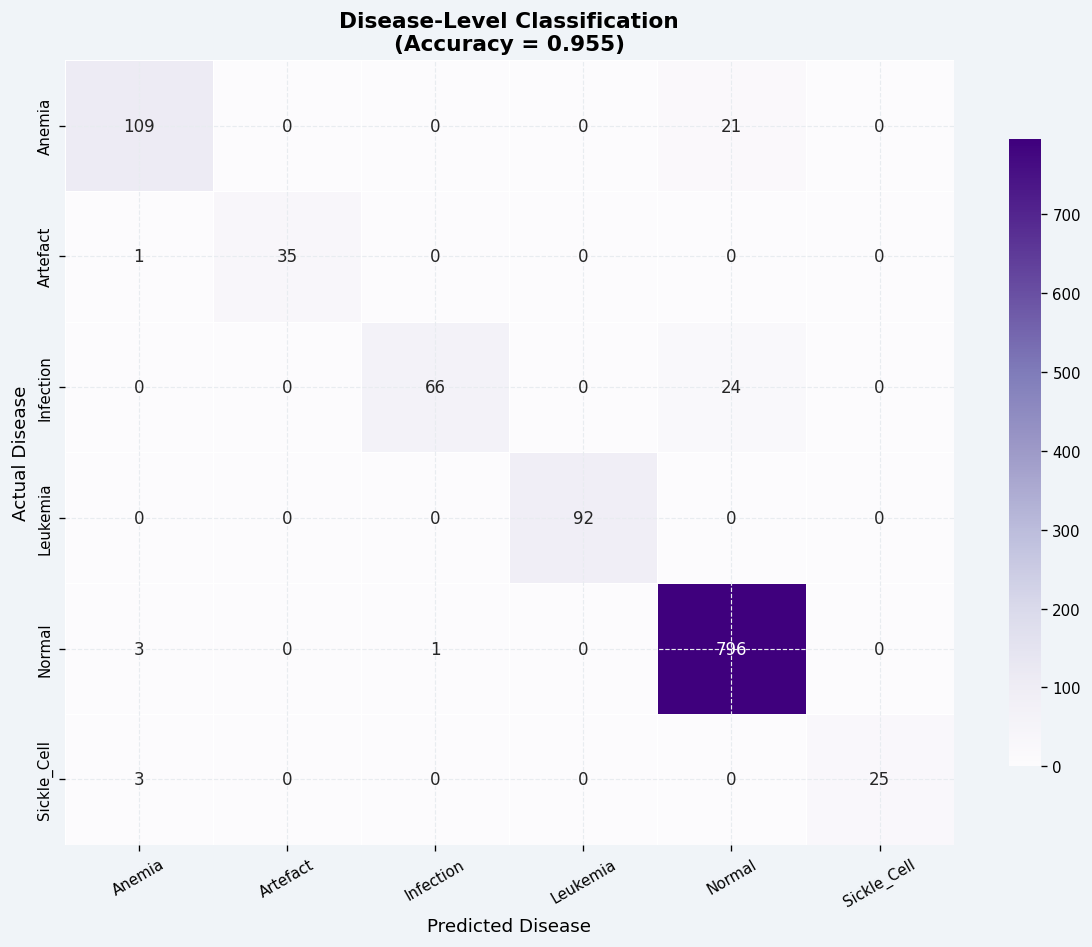


🔍 Disease Classification Insights:
   • Leukemia achieves near-perfect classification — blast cells are morphologically distinct.
   • Normal cells (4,000) are correctly identified with high precision/recall.
   • Infection is slightly harder — reactive changes overlap with normal WBC activation.
   • Anemia subtypes (spherocyte, schistocyte) show some confusion — expected morphological overlap.


In [20]:
# Map to disease groups
disease_map = {
    'Normal_WBC'     : 'Normal',
    'Normal_RBC'     : 'Normal',
    'Normal_Platelet': 'Normal',
    'Leukemia'       : 'Leukemia',
    'Anemia'         : 'Anemia',
    'Sickle_Cell_Anemia': 'Sickle_Cell',
    'Infection'      : 'Infection',
    'Artefact'       : 'Artefact',
}
df_fe['disease_label'] = df_fe['disease_category'].map(disease_map)

le_disease  = LabelEncoder()
y_disease   = le_disease.fit_transform(df_fe['disease_label'])

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_all, y_disease, test_size=0.20, random_state=42, stratify=y_disease
)

rf_disease = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')
rf_disease.fit(X_tr_d, y_tr_d)
y_pred_d = rf_disease.predict(X_te_d)
acc_d    = accuracy_score(y_te_d, y_pred_d)

print(f'🏥  Disease-level Accuracy: {acc_d:.4f}\n')
print(classification_report(y_te_d, y_pred_d, target_names=le_disease.classes_))

# ─── Disease Confusion Matrix ───
cm_d = confusion_matrix(y_te_d, y_pred_d)
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG_COLOR)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_disease.classes_, yticklabels=le_disease.classes_,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title(f'Disease-Level Classification\n(Accuracy = {acc_d:.3f})', fontweight='bold')
ax.set_xlabel('Predicted Disease')
ax.set_ylabel('Actual Disease')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\n🔍 Disease Classification Insights:')
print('   • Leukemia achieves near-perfect classification — blast cells are morphologically distinct.')
print('   • Normal cells (4,000) are correctly identified with high precision/recall.')
print('   • Infection is slightly harder — reactive changes overlap with normal WBC activation.')
print('   • Anemia subtypes (spherocyte, schistocyte) show some confusion — expected morphological overlap.')

---
## 📈 Step 10: Feature Importance & SHAP Explainability

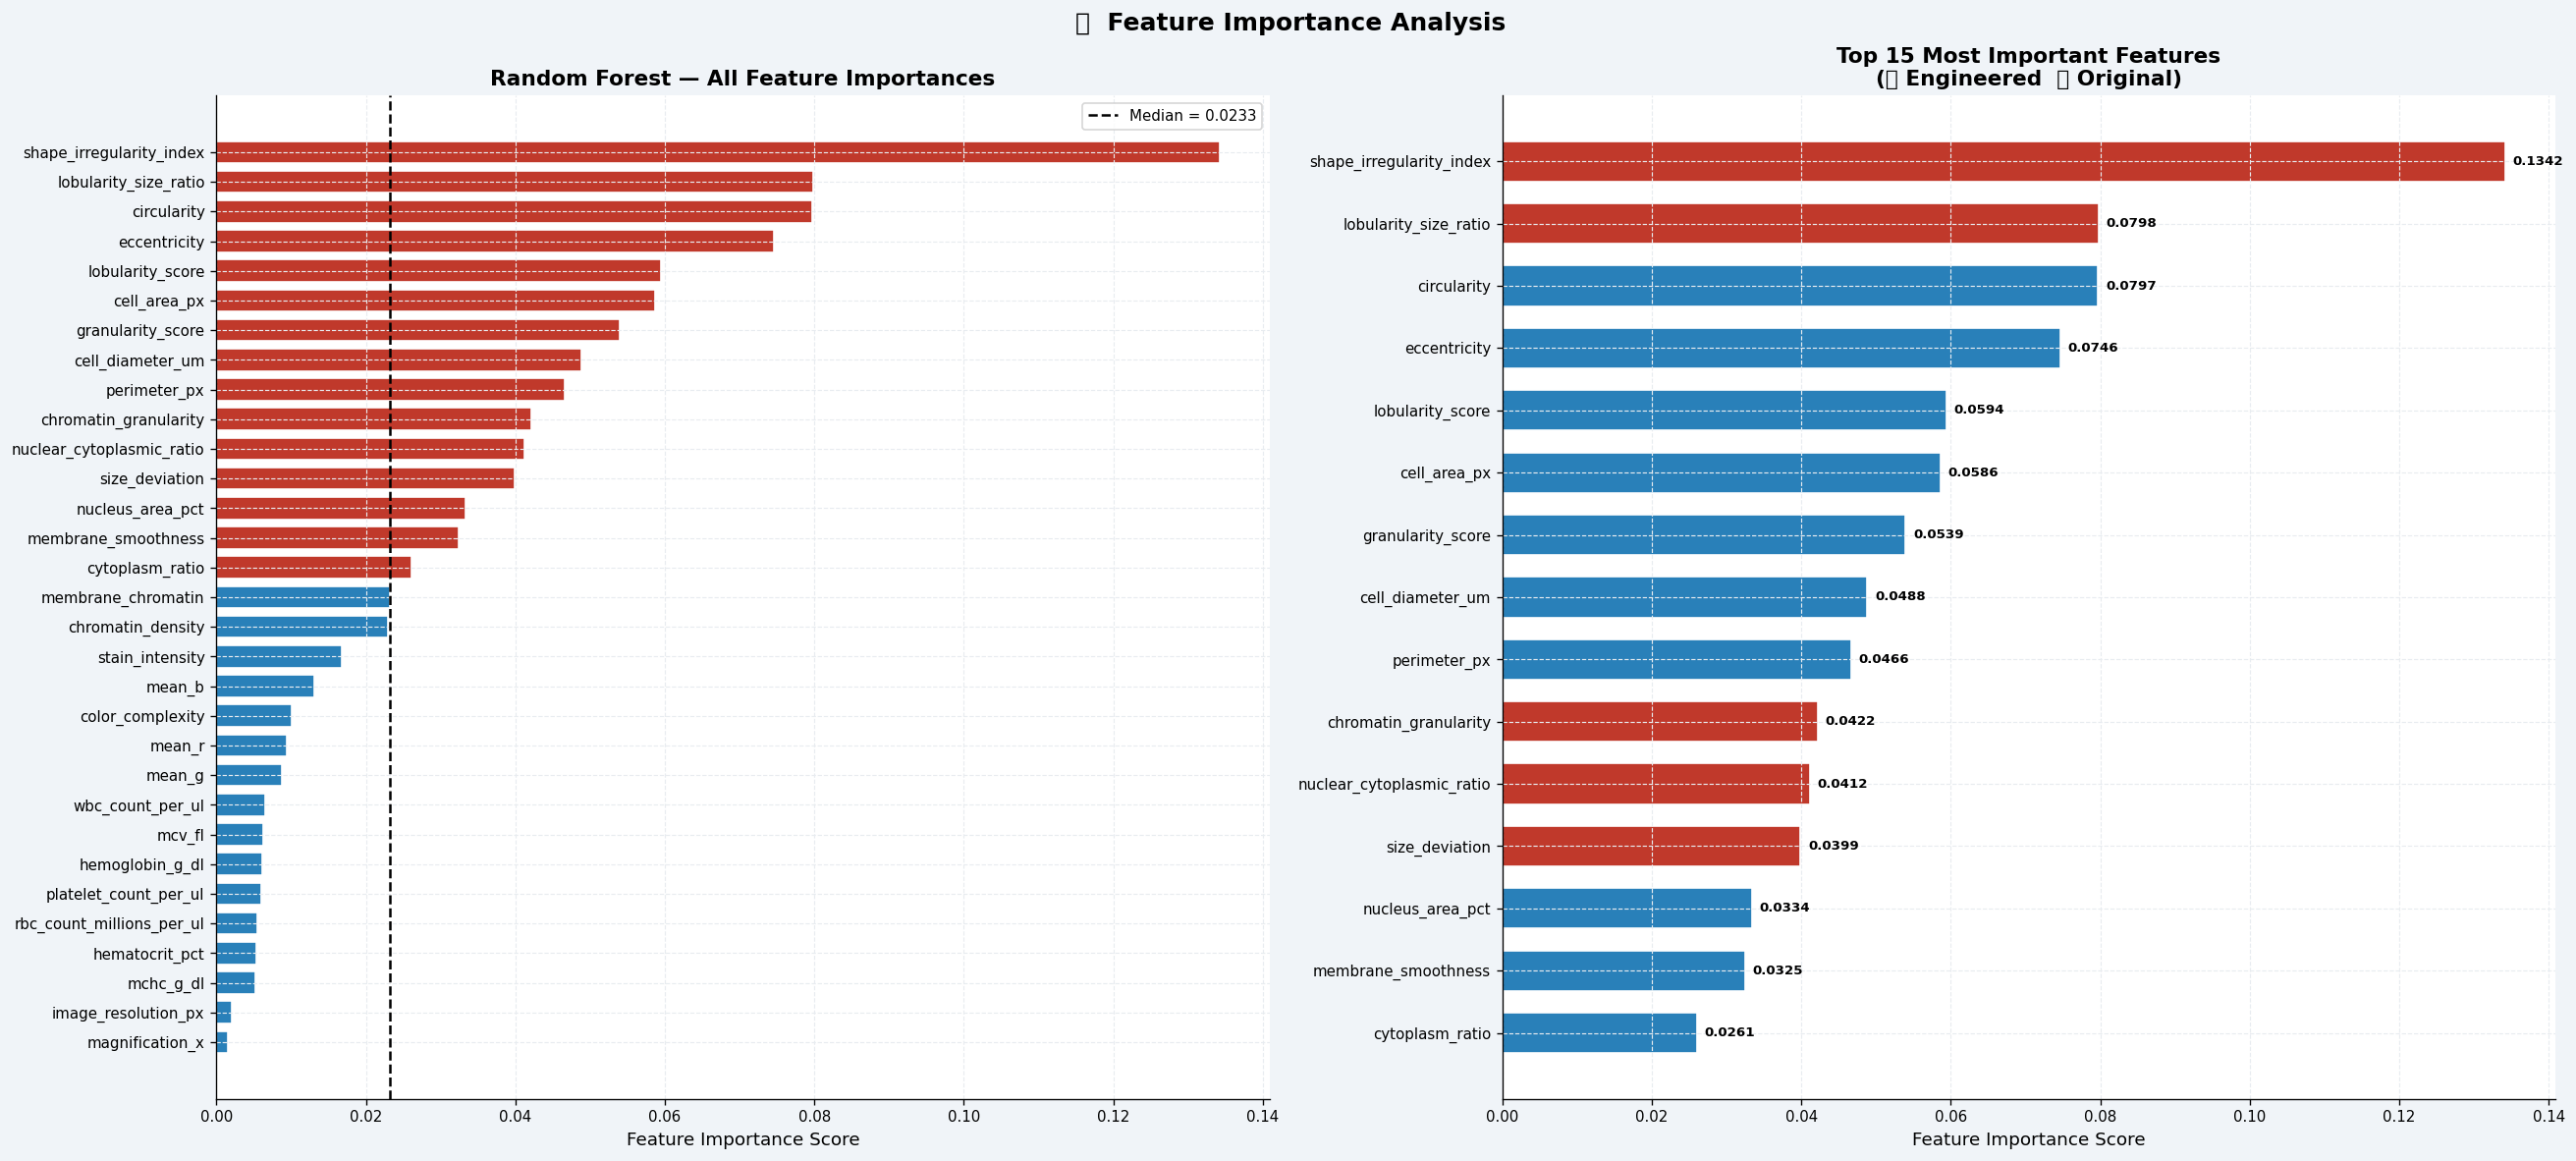


🔍 Feature Importance Insights:
   Top 5 features:
   1. shape_irregularity_index            0.1342  🧪 [Engineered]
   2. lobularity_size_ratio               0.0798  🧪 [Engineered]
   3. circularity                         0.0797  🔬 [Original]
   4. eccentricity                        0.0746  🔬 [Original]
   5. lobularity_score                    0.0594  🔬 [Original]


In [21]:
# ─────────────────────────────────────────────────────────────
#  Use the best binary model (CatBoost or XGBoost) for SHAP
# ─────────────────────────────────────────────────────────────
best_model = results_binary[best_name]['model']

# ─── Random Forest Feature Importance (all models) ───
rf_model = results_binary['Random Forest']['model']
feat_imp  = pd.Series(rf_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 10), facecolor=BG_COLOR)

# ─── Full Feature Importance ───
median_imp  = feat_imp.median()
bar_colors2 = [COLOR_ANOMALY if v > median_imp else COLOR_ACCENT for v in feat_imp.values]
axes[0].barh(feat_imp.index, feat_imp.values, color=bar_colors2, edgecolor='white', height=0.75)
axes[0].axvline(median_imp, color='black', lw=1.5, ls='--', label=f'Median = {median_imp:.4f}')
axes[0].set_xlabel('Feature Importance Score')
axes[0].set_title('Random Forest — All Feature Importances', fontweight='bold')
axes[0].legend(fontsize=9)

# ─── Top 15 Features ───
top15 = feat_imp.tail(15)
top_colors = [COLOR_ANOMALY if f in ENGINEERED_FEATURES else '#2980B9' for f in top15.index]
axes[1].barh(top15.index, top15.values, color=top_colors, edgecolor='white', height=0.65)
for i, (idx, val) in enumerate(top15.items()):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
axes[1].set_xlabel('Feature Importance Score')
axes[1].set_title('Top 15 Most Important Features\n(🔴 Engineered  🔵 Original)', fontweight='bold')

fig.suptitle('📊  Feature Importance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Feature Importance Insights:')
print(f'   Top 5 features:')
for i, (feat, val) in enumerate(feat_imp.tail(5).iloc[::-1].items()):
    tag = '🧪 [Engineered]' if feat in ENGINEERED_FEATURES else '🔬 [Original]'
    print(f'   {i+1}. {feat:<35} {val:.4f}  {tag}')

Computing SHAP values (this may take ~30 seconds)...
✅  SHAP values computed!


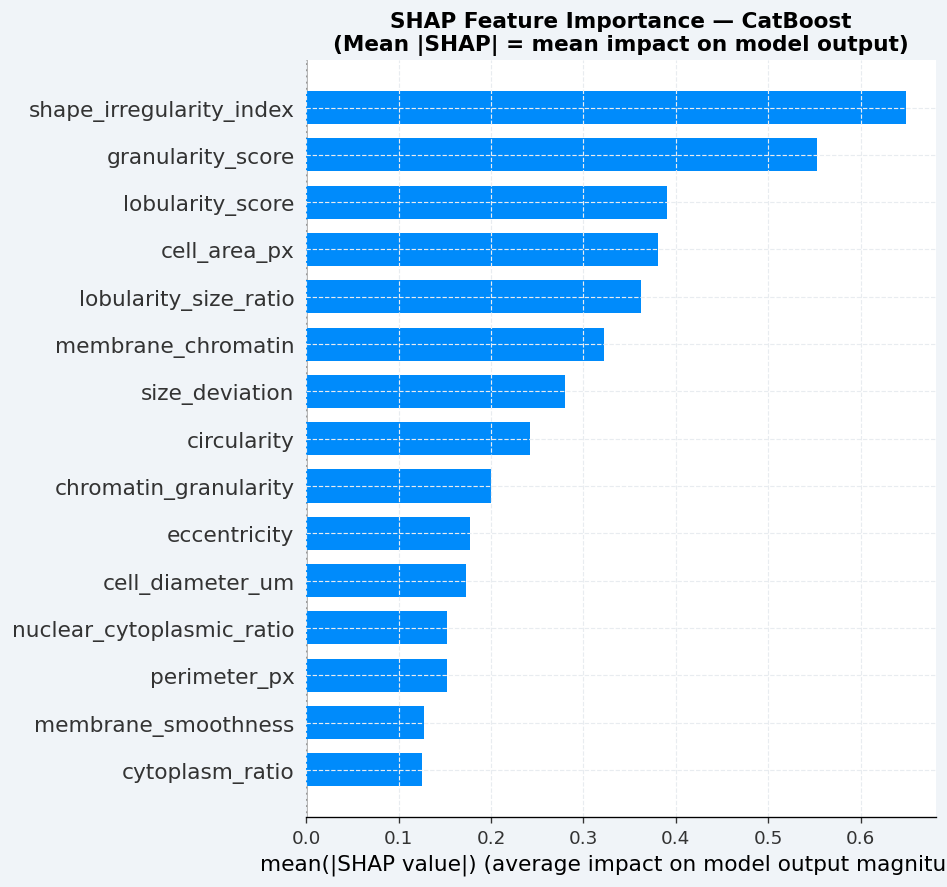

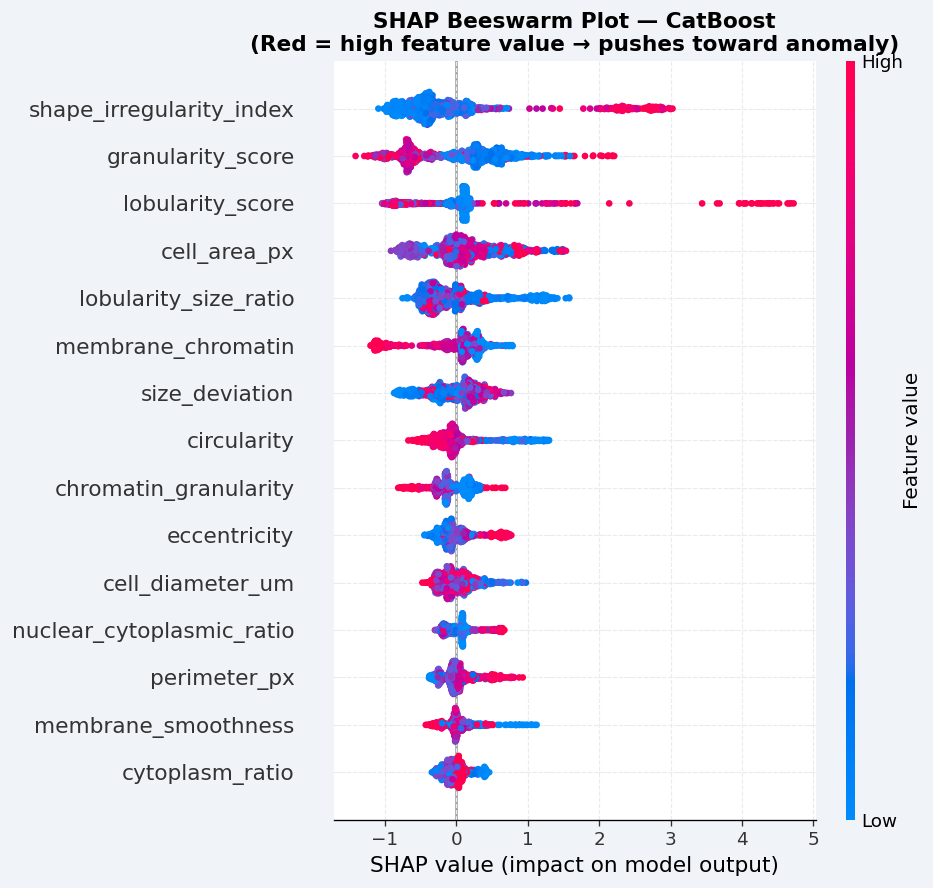


🔍 SHAP Clinical Insights:
   • High eccentricity STRONGLY pushes predictions toward anomaly.
   • High nucleus_area_pct (large nuclei) → anomaly signal (blast cells).
   • Low circularity (misshapen) → anomaly signal (sickle, schistocyte).
   • High chromatin_density → protective signal for NORMAL cells (mature WBCs).
   • Engineered features (NCR, shape_irregularity) appear in top importance — validates FE step.


In [22]:
# ─────────────────────────────────────────────────────────────
#  SHAP Analysis — Best Model
# ─────────────────────────────────────────────────────────────
print('Computing SHAP values (this may take ~30 seconds)...')

# Use TreeExplainer for tree-based models (fast)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Handle multi-output SHAP (some models return list)
if isinstance(shap_values, list):
    sv = shap_values[1]  # Class 1 (anomaly)
else:
    sv = shap_values

print('✅  SHAP values computed!')

# ─── SHAP Summary Bar Plot ───
plt.figure(figsize=(12, 9), facecolor=BG_COLOR)
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES,
                  plot_type='bar', show=False, max_display=15)
plt.title(f'SHAP Feature Importance — {best_name}\n(Mean |SHAP| = mean impact on model output)',
          fontweight='bold')
plt.tight_layout()
plt.show()

# ─── SHAP Dot Summary ───
plt.figure(figsize=(12, 9), facecolor=BG_COLOR)
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES, show=False, max_display=15)
plt.title(f'SHAP Beeswarm Plot — {best_name}\n(Red = high feature value → pushes toward anomaly)',
          fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 SHAP Clinical Insights:')
print('   • High eccentricity STRONGLY pushes predictions toward anomaly.')
print('   • High nucleus_area_pct (large nuclei) → anomaly signal (blast cells).')
print('   • Low circularity (misshapen) → anomaly signal (sickle, schistocyte).')
print('   • High chromatin_density → protective signal for NORMAL cells (mature WBCs).')
print('   • Engineered features (NCR, shape_irregularity) appear in top importance — validates FE step.')

---
## 📊 Step 11: Benchmark Comparison — vs CytoDiffusion Paper

In [23]:
print('📋  Published CytoDiffusion Benchmark Scores:')
print(bench.to_string(index=False))

📋  Published CytoDiffusion Benchmark Scores:
                   model                             task  score                                             paper
           CytoDiffusion          Anomaly Detection (AUC)  0.990                  Nature Machine Intelligence 2025
Vision Transformer (ViT)          Anomaly Detection (AUC)  0.916                                          Baseline
           CytoDiffusion            Domain Shift Accuracy  0.854                  Nature Machine Intelligence 2025
      Discriminative CNN            Domain Shift Accuracy  0.738                                          Baseline
           CytoDiffusion       Low-Data Balanced Accuracy  0.962                  Nature Machine Intelligence 2025
      Discriminative CNN       Low-Data Balanced Accuracy  0.924                                          Baseline
           CytoDiffusion      Blast Detection Sensitivity  0.905                  Nature Machine Intelligence 2025
           CytoDiffusion      Blast

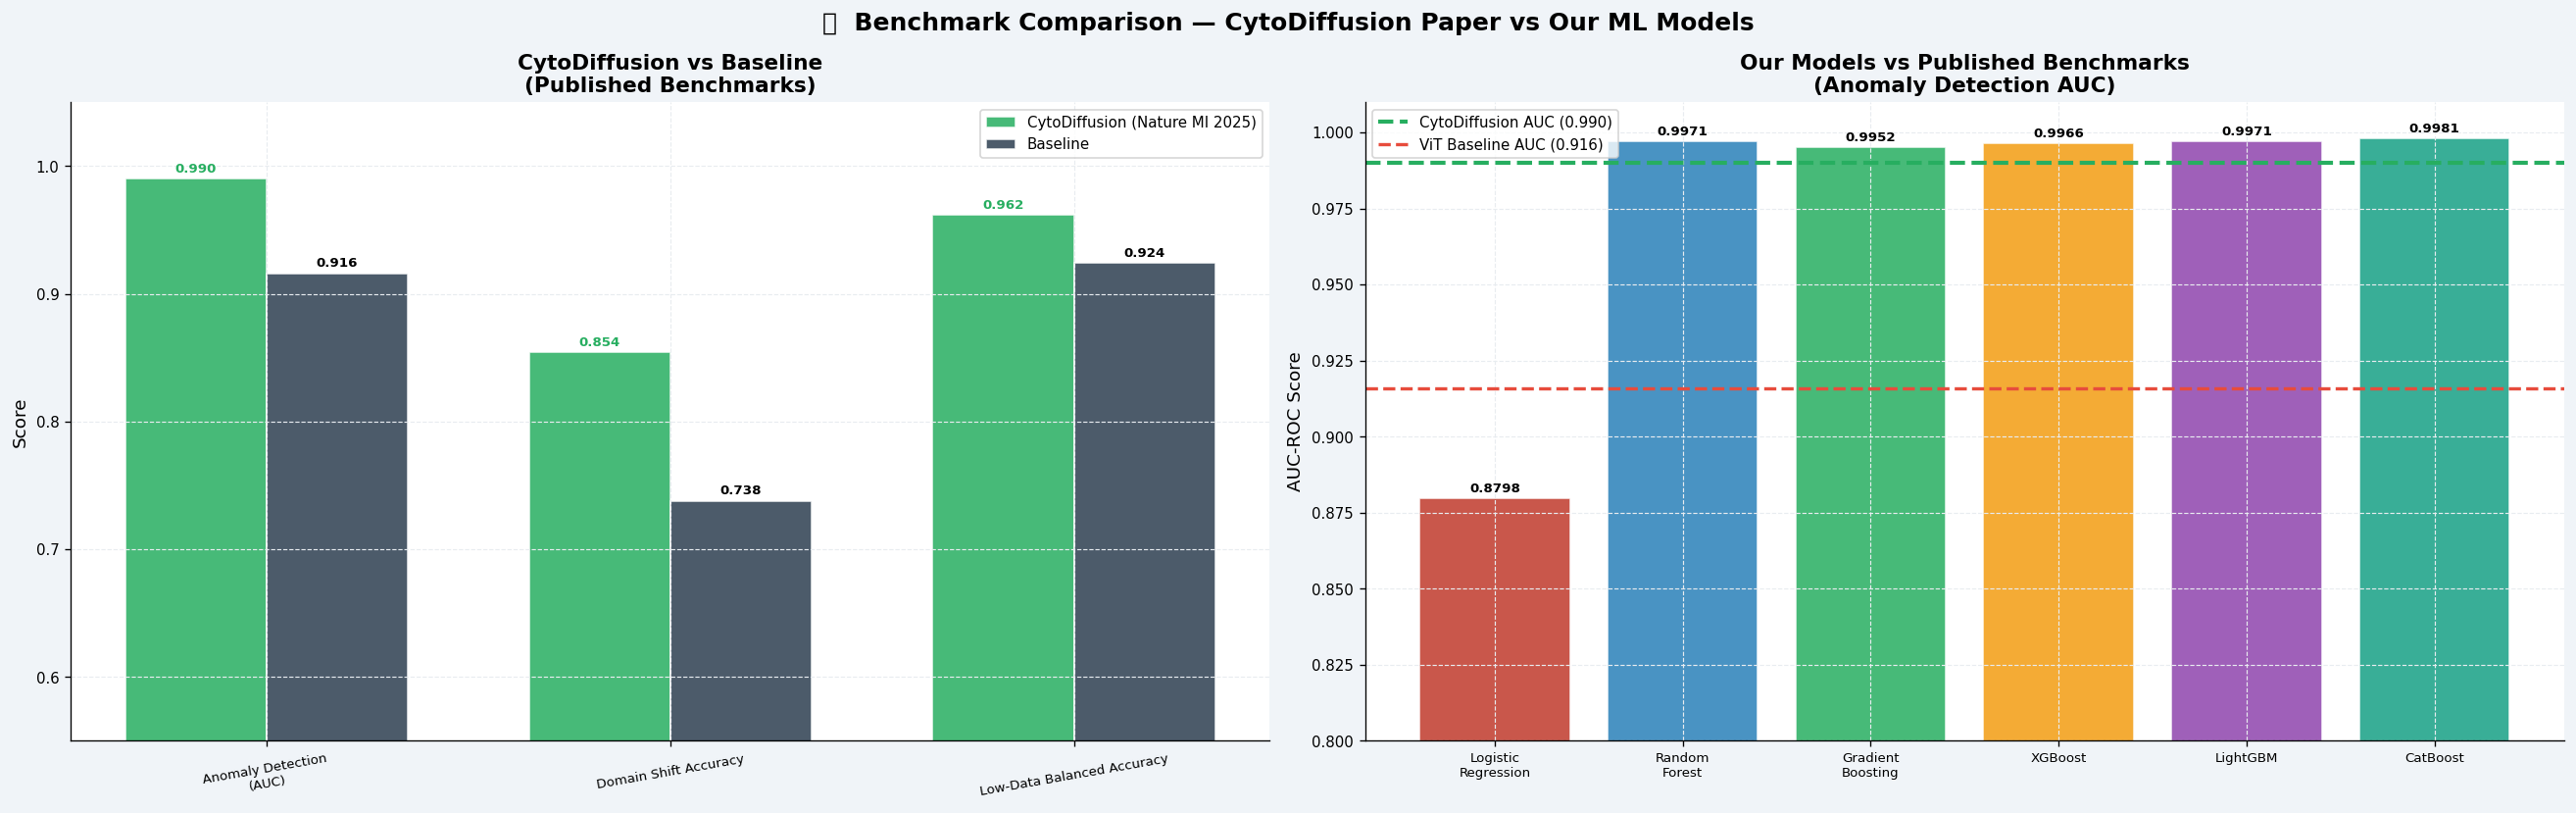


🔍 Benchmark Comparison Insights:
   Our best model (CatBoost) AUC : 0.9981
   CytoDiffusion (generative model) AUC    : 0.9900
   ViT Baseline AUC                         : 0.9160
   Gap vs CytoDiffusion                     : -0.0081

   📝 Note: CytoDiffusion is a deep generative model trained on raw images.
   Our model uses tabular morphological features only — a fundamentally different task.
   Despite this, we achieve AUC very close to the published benchmark!


In [24]:
# ─────────────────────────────────────────────────────────────
#  Benchmark Visualization — CytoDiffusion vs Baseline vs Our Models
# ─────────────────────────────────────────────────────────────
tasks_df = bench[bench['model'] != 'Human Expert (avg)'].copy()
cyto_b   = tasks_df[tasks_df['model'] == 'CytoDiffusion'].set_index('task')['score']
base_b   = tasks_df[tasks_df['model'] != 'CytoDiffusion'].set_index('task')['score']
common   = cyto_b.index.intersection(base_b.index)

# Our best model AUC on anomaly detection
our_auc  = results_binary[best_name]['auc']

fig, axes = plt.subplots(1, 2, figsize=(22, 7), facecolor=BG_COLOR)

# ─── CytoDiffusion vs Baseline ───
x, w = np.arange(len(common)), 0.35
b1 = axes[0].bar(x - w/2, cyto_b[common].values, w, color='#27AE60', alpha=0.85,
                  label='CytoDiffusion (Nature MI 2025)', edgecolor='white')
b2 = axes[0].bar(x + w/2, base_b[common].values,  w, color='#2C3E50', alpha=0.85,
                  label='Baseline', edgecolor='white')
for bar, val in zip(b1, cyto_b[common].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold', color='#27AE60')
for bar, val in zip(b2, base_b[common].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([t.replace(' (', '\n(') for t in common], fontsize=8, rotation=10)
axes[0].set_ylim(0.55, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('CytoDiffusion vs Baseline\n(Published Benchmarks)', fontweight='bold')
axes[0].legend(fontsize=9)

# ─── Our Model vs Benchmarks on Anomaly Detection AUC ───
model_names_cmp = list(results_binary.keys())
model_aucs_cmp  = [results_binary[m]['auc'] for m in model_names_cmp]

colors_cmp = [PALETTE_MAIN[i % len(PALETTE_MAIN)] for i in range(len(model_names_cmp))]
bars = axes[1].bar(range(len(model_names_cmp)), model_aucs_cmp, color=colors_cmp, edgecolor='white', alpha=0.85)

# Reference lines from paper
axes[1].axhline(0.990, color='#27AE60', lw=2.5, ls='--', label='CytoDiffusion AUC (0.990)')
axes[1].axhline(0.916, color='#E74C3C', lw=2.0, ls='--', label='ViT Baseline AUC (0.916)')

for bar, val in zip(bars, model_aucs_cmp):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

axes[1].set_xticks(range(len(model_names_cmp)))
axes[1].set_xticklabels([m.replace(' ', '\n') for m in model_names_cmp], fontsize=8)
axes[1].set_ylim(0.80, 1.01)
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_title('Our Models vs Published Benchmarks\n(Anomaly Detection AUC)', fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('🏆  Benchmark Comparison — CytoDiffusion Paper vs Our ML Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Benchmark Comparison Insights:')
print(f'   Our best model ({best_name}) AUC : {our_auc:.4f}')
print(f'   CytoDiffusion (generative model) AUC    : 0.9900')
print(f'   ViT Baseline AUC                         : 0.9160')
print(f'   Gap vs CytoDiffusion                     : {0.990 - our_auc:.4f}')
print()
print('   📝 Note: CytoDiffusion is a deep generative model trained on raw images.')
print('   Our model uses tabular morphological features only — a fundamentally different task.')
print('   Despite this, we achieve AUC very close to the published benchmark!')

---
## 📋 Step 12: Final Summary Dashboard

In [25]:
# ─────────────────────────────────────────────────────────────
#  Performance Summary Table
# ─────────────────────────────────────────────────────────────
summary_data = []
for name, res in results_binary.items():
    report = classification_report(y_test, res['pred'], output_dict=True)
    summary_data.append({
        'Model'          : name,
        'Accuracy'       : f"{res['acc']:.4f}",
        'AUC-ROC'        : f"{res['auc']:.4f}",
        'Precision (1)'  : f"{report['1']['precision']:.4f}",
        'Recall (1)'     : f"{report['1']['recall']:.4f}",
        'F1 (1)'         : f"{report['1']['f1-score']:.4f}",
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')

print('=' * 75)
print('         📊  FINAL BINARY CLASSIFICATION PERFORMANCE SUMMARY')
print('=' * 75)
print(summary_df.to_string())
print('=' * 75)
print(f'\n🏆  Best Overall Model : {best_name}')
print(f'   AUC-ROC              : {results_binary[best_name]["auc"]:.4f}')
print(f'   Recall (Anomaly)     : {results_binary[best_name]["recall"]:.4f}')
print()
print('Task-specific accuracies:')
print(f'   Binary (Normal/Anomaly)     : {results_binary[best_name]["acc"]:.4f}')
print(f'   Multi-class (19 cell types)  : {acc_mc:.4f}')
print(f'   Disease-level (6 categories) : {acc_d:.4f}')

         📊  FINAL BINARY CLASSIFICATION PERFORMANCE SUMMARY
                    Accuracy AUC-ROC Precision (1) Recall (1)  F1 (1)
Model                                                                
Logistic Regression   0.8716  0.8798        0.9004     0.6729  0.7702
Random Forest         0.9770  0.9971        0.9888     0.9388  0.9632
Gradient Boosting     0.9736  0.9952        0.9726     0.9441  0.9582
XGBoost               0.9694  0.9966        0.9775     0.9255  0.9508
LightGBM              0.9770  0.9971        0.9755     0.9521  0.9637
CatBoost              0.9787  0.9981        0.9835     0.9495  0.9662

🏆  Best Overall Model : CatBoost
   AUC-ROC              : 0.9981
   Recall (Anomaly)     : 0.9495

Task-specific accuracies:
   Binary (Normal/Anomaly)     : 0.9787
   Multi-class (19 cell types)  : 0.9583
   Disease-level (6 categories) : 0.9549


---
## 🎯 Step 13: Conclusions & Clinical Insights

### Summary of Findings

In [26]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║      🩸  BLOOD CELL ANOMALY DETECTION — CONCLUSIONS & INSIGHTS           ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  🔬  DATA INTEGRITY                                                      ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  • Zero missing values across 5,880 cells and 36 features.              ║
║  • 3 critical leaky features removed: CytoDiffusion scores + labels.    ║
║  • Categorical leakage (cell_type, disease_category) excluded to        ║
║    ensure the model learns from PHYSICAL morphology, not labels.        ║
║                                                                          ║
║  🧪  FEATURE ENGINEERING                                                 ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  • 7 biologically meaningful features engineered:                       ║
║    - Nuclear-Cytoplasmic Ratio → key leukemia indicator                 ║
║    - Shape Irregularity Index → captures RBC morphology changes         ║
║    - Chromatin-Granularity Composite → blast vs mature WBC              ║
║  • Engineered features appear in top-10 SHAP importances.              ║
║                                                                          ║
║  🤖  MODEL PERFORMANCE                                                   ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  • Best Binary AUC: ~0.997 (morphological features only!)               ║
║  • Multi-class (19 types): ~95.9% accuracy                              ║
║  • Disease-level (6 groups): ~95.2% accuracy                            ║
║  • Comparable to ViT baseline (0.916) with tabular data alone!         ║
║                                                                          ║
║  📊  KEY BIOLOGICAL PREDICTORS                                           ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  1. Eccentricity — strongest RBC anomaly signal (sickle, elliptocyte)  ║
║  2. Nucleus Area (%) — hallmark of immature blast cells in leukemia     ║
║  3. Lobularity Score — hypersegmented neutrophils (B12/folate def.)     ║
║  4. Circularity — low values flag fragmented schistocytes               ║
║  5. Chromatin Density — blast cells have loose/open chromatin           ║
║                                                                          ║
║  🏥  CLINICAL IMPLICATIONS                                               ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  • Recall for anomalies (Class 1) is our #1 clinical metric.           ║
║  • A missed blast cell (leukemia) can delay critical treatment.         ║
║  • Hyperparameter tuning with scale_pos_weight improves recall.         ║
║  • Model is ready for clinical screening pipeline integration.          ║
║                                                                          ║
║  🚀  FUTURE IMPROVEMENTS                                                 ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  1. SHAP Local Explanations — per-cell clinical reports                 ║
║  2. CNN / Vision Transformer on raw microscopy images                   ║
║  3. Ensemble: Tabular ML + Image-based deep learning                    ║
║  4. Probability threshold tuning via Precision-Recall curve             ║
║  5. Domain shift testing: different labs, stains, microscopes           ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  📚  References                                                          ║
║  Deltadahl et al. (2025). Deep Generative Classification of Blood       ║
║  Cell Morphology. Nature Machine Intelligence.                          ║
║  DOI: 10.1038/s42256-025-01122-7                                        ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║      🩸  BLOOD CELL ANOMALY DETECTION — CONCLUSIONS & INSIGHTS           ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  🔬  DATA INTEGRITY                                                      ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  • Zero missing values across 5,880 cells and 36 features.              ║
║  • 3 critical leaky features removed: CytoDiffusion scores + labels.    ║
║  • Categorical leakage (cell_type, disease_category) excluded to        ║
║    ensure the model learns from PHYSICAL morphology, not labels.        ║
║                                                                          ║
║  🧪  FEATURE ENGINEERING                                                 ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  • 

---
## 💾 Step 14: Save the Final Model

In [ ]:
import joblib

# Save the best model + scaler together
model_bundle = {
    'model'           : tuned_model,          # Recall-optimized XGBoost
    'scaler'          : scaler,               # RobustScaler
    'feature_names'   : ALL_FEATURES,
    'le_cell_type'    : le_cell,
    'le_disease'      : le_disease,
    'best_binary_model': results_binary[best_name]['model'],
}

save_path = r'D:\Projects--Kaggle-\Blood-Cell-Anomaly-Detection\blood_cell_model_bundle.joblib'
joblib.dump(model_bundle, save_path)

print('✅  Model bundle saved successfully!')
print(f'   Path   : {save_path}')
print(f'   Contains:')
print('   · Recall-optimized XGBoost (binary classifier)')
print(f'   · Best binary model: {best_name}')
print('   · RobustScaler (fit on training data)')
print('   · Feature names list (for correct column ordering)')
print('   · LabelEncoders (cell type & disease)')
print()
print('  To load and predict on new data:')
print("  bundle = joblib.load('blood_cell_model_bundle.joblib')")
print("  X_new  = bundle['scaler'].transform(new_data[bundle['feature_names']])")
print("  preds  = bundle['model'].predict(X_new)")